In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [20]:
import os

# Change to the Downloads folder
os.chdir(os.path.expanduser("~\\Downloads"))

# Verify current working directory
print("Current Directory:", os.getcwd())


Current Directory: C:\Users\Dell\Downloads


In [28]:
df = pd.read_excel('sales.xlsx')
df.head()

,Time_Stamp,RetailSales
0,2000-01-01,4243
1,2000-02-01,4952
2,2000-03-01,6008
3,2000-04-01,5353
4,2000-05-01,6435


In [30]:
df.set_index('Time_Stamp',inplace=True)
df.head()

,RetailSales
Time_Stamp,
2000-01-01,4243
2000-02-01,4952
2000-03-01,6008
2000-04-01,5353
2000-05-01,6435


### Plot the Time Series to understand the behaviour of the data.

In [33]:
# The following code is to set the subsequent figure sizes

from pylab import rcParams
rcParams['figure.figsize'] = 20,8

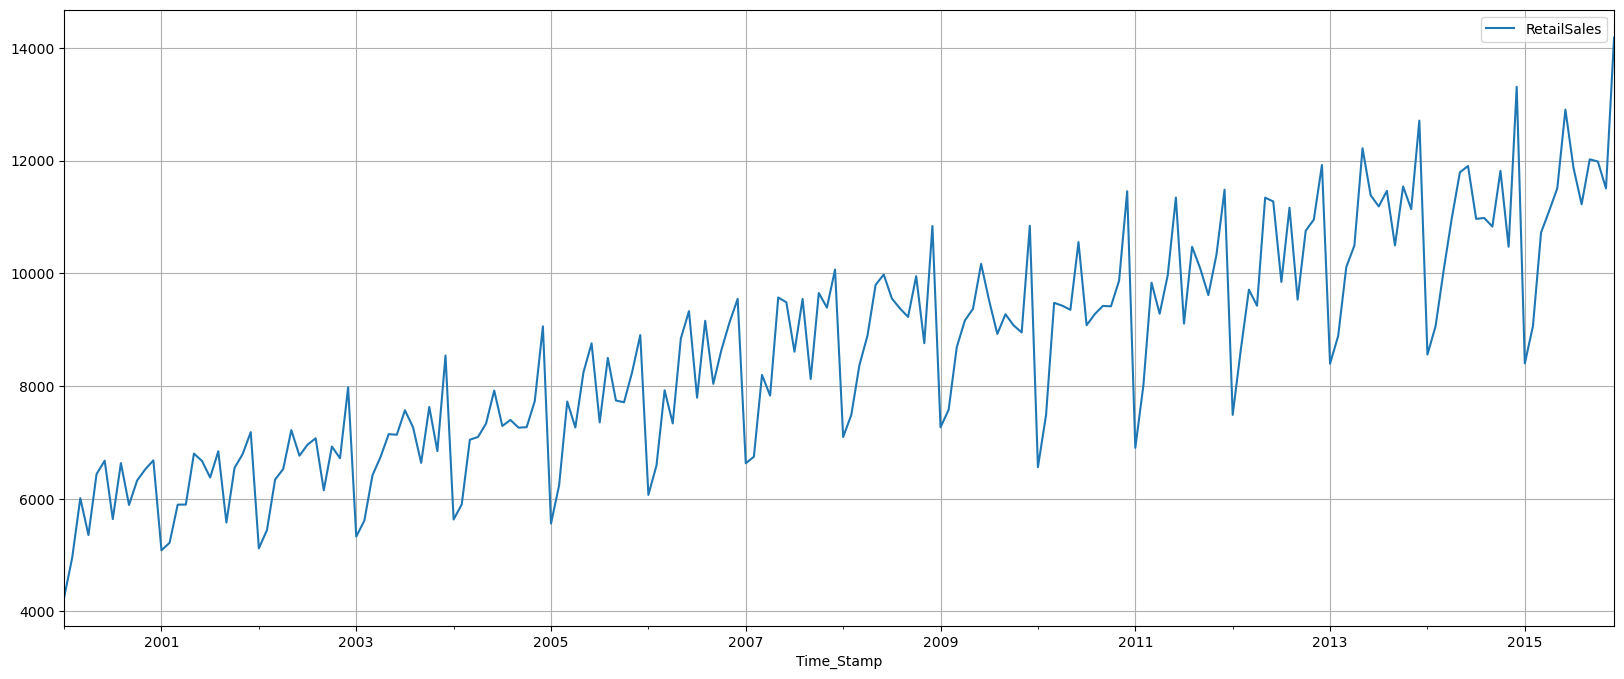

In [35]:
df.plot()
plt.grid();

We can see that there is a slight upward trend with a seasonal pattern associated as well.

### Check the basic measures of descriptive statistics

In [39]:
df.describe()

,RetailSales
count,192.000000
mean,8618.291667
std,1984.575310
min,4243.000000
25%,7023.250000
50%,8664.500000
75%,9969.500000
max,14183.000000


## Plot a boxplot to understand the spread of sales across different years and within different months across years.

### Yearly Boxplot

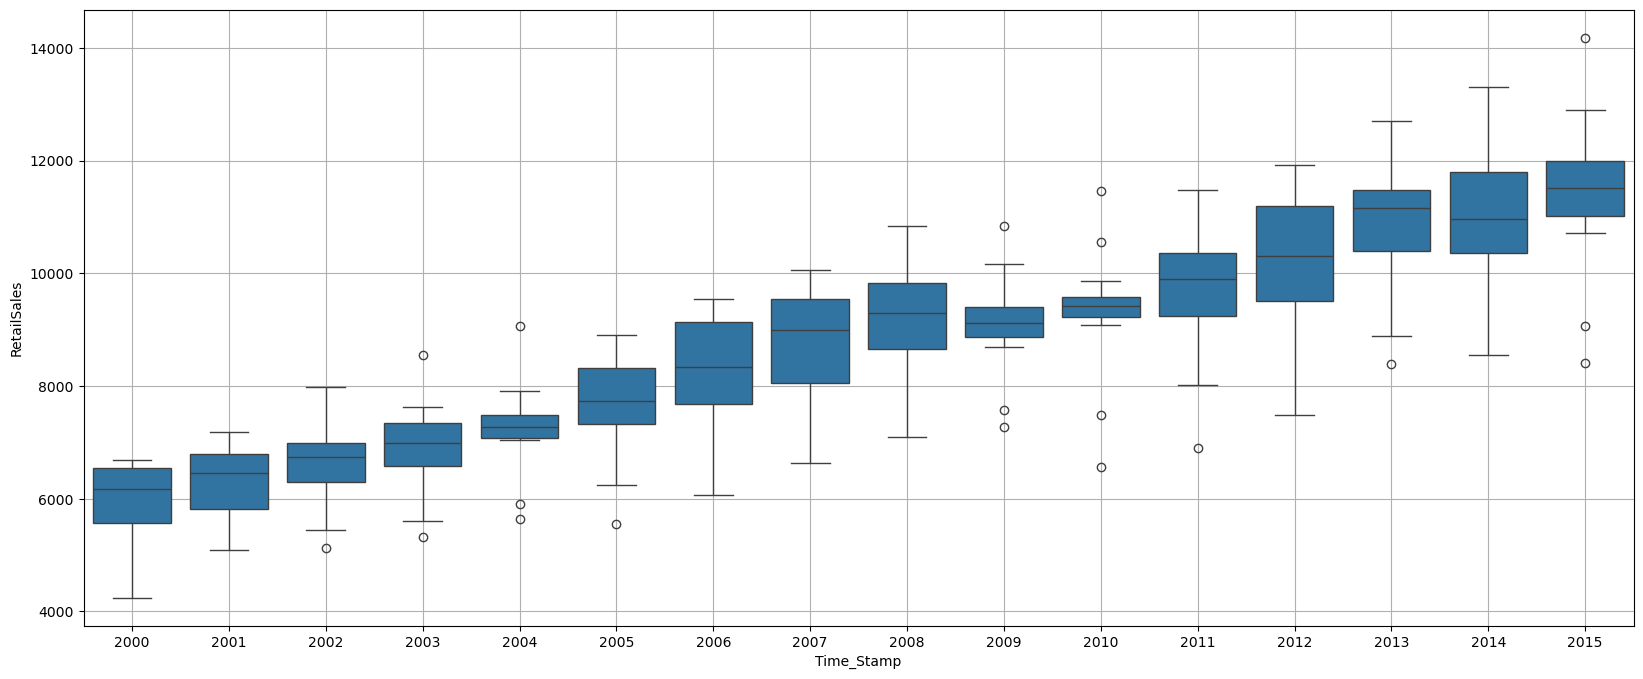

In [44]:
sns.boxplot(x = df.index.year,y = df['RetailSales'])
plt.grid();

## Monthly Plot

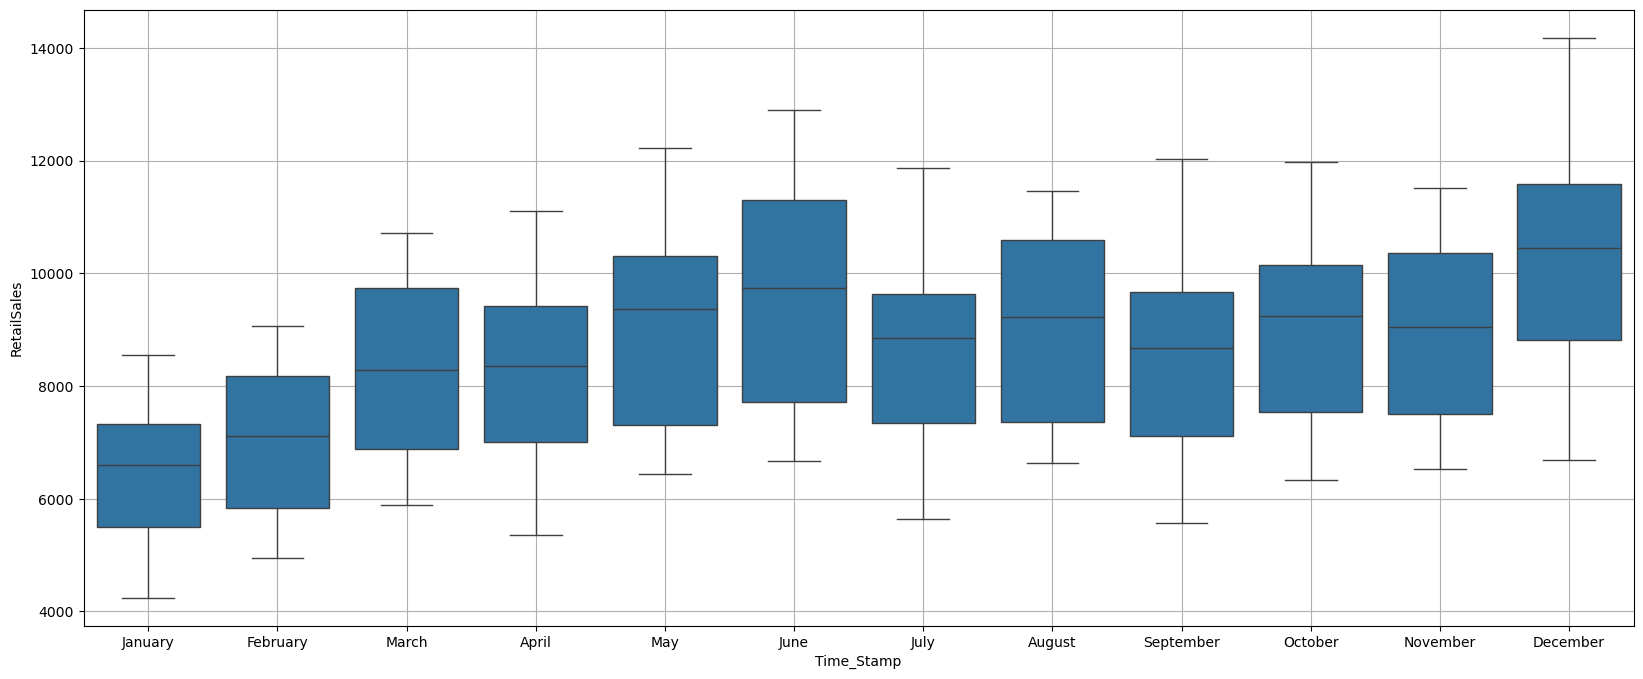

In [48]:
sns.boxplot(x = df.index.month_name(),y = df['RetailSales'])
plt.grid();

# Plot a time series monthplot to understand the spread of accidents across different years and within different months across years.

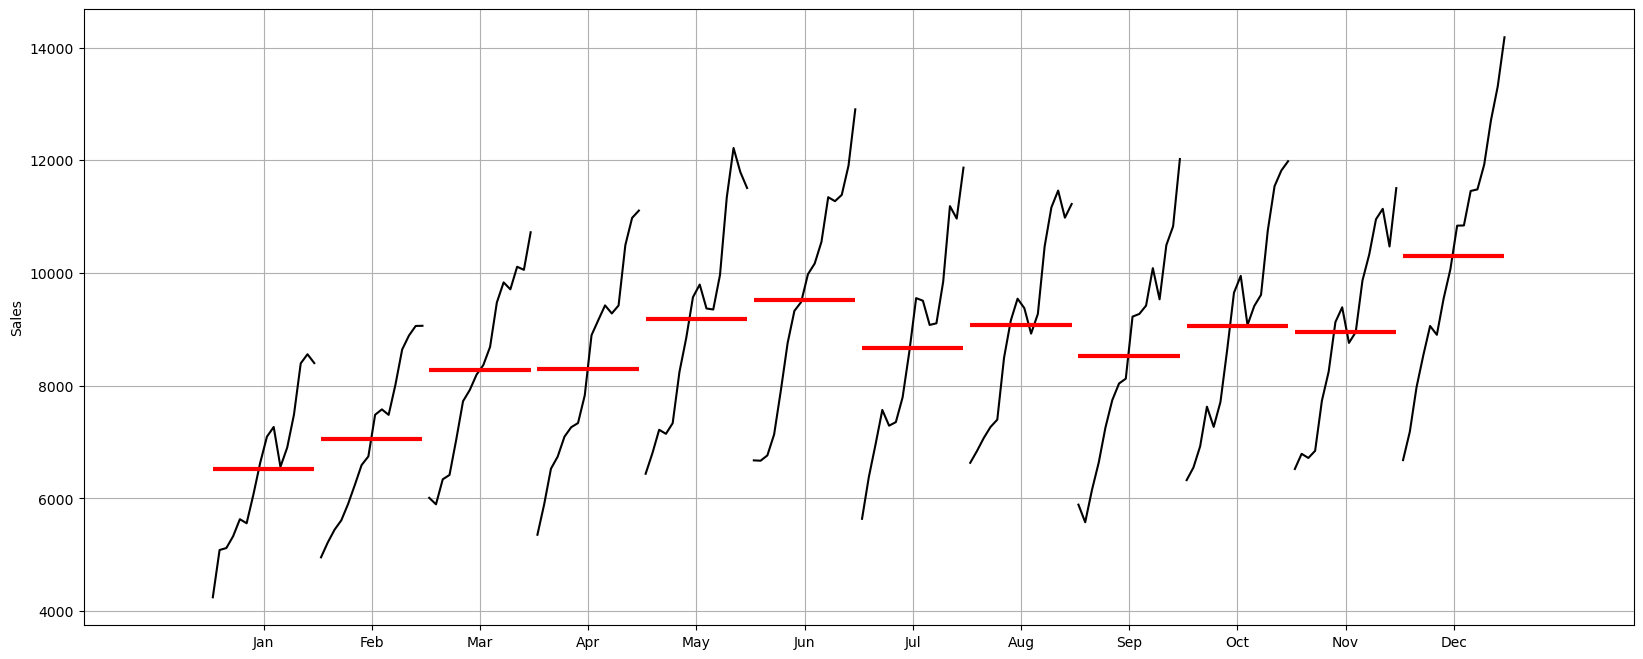

In [51]:
from statsmodels.graphics.tsaplots import month_plot

month_plot(df['RetailSales'],ylabel='Sales')
plt.grid();

# Plot a graph of monthly RetailSales across years.

In [54]:
monthly_sales_across_years = pd.pivot_table(df, values = 'RetailSales', columns = df.index.month, index = df.index.year)
monthly_sales_across_years

Time_Stamp,1,2,3,4,5,6,7,8,9,10,11,12
Time_Stamp,,,,,,,,,,,,
2000,4243.0,4952.0,6008.0,5353.0,6435.0,6673.0,5636.0,6630.0,5887.0,6322.0,6520.0,6678.0
2001,5082.0,5216.0,5893.0,5894.0,6799.0,6667.0,6374.0,6840.0,5575.0,6545.0,6789.0,7180.0
2002,5117.0,5442.0,6337.0,6525.0,7216.0,6761.0,6958.0,7070.0,6148.0,6924.0,6716.0,7975.0
2003,5326.0,5609.0,6414.0,6741.0,7144.0,7133.0,7568.0,7266.0,6634.0,7626.0,6843.0,8540.0
2004,5629.0,5898.0,7045.0,7094.0,7333.0,7918.0,7289.0,7396.0,7259.0,7268.0,7731.0,9058.0
2005,5557.0,6237.0,7723.0,7262.0,8241.0,8757.0,7352.0,8496.0,7741.0,7710.0,8247.0,8902.0
2006,6066.0,6590.0,7923.0,7335.0,8843.0,9327.0,7792.0,9156.0,8037.0,8640.0,9128.0,9545.0
2007,6627.0,6743.0,8195.0,7828.0,9570.0,9484.0,8608.0,9543.0,8123.0,9649.0,9390.0,10065.0
2008,7093.0,7483.0,8365.0,8895.0,9794.0,9977.0,9553.0,9375.0,9225.0,9948.0,8758.0,10839.0


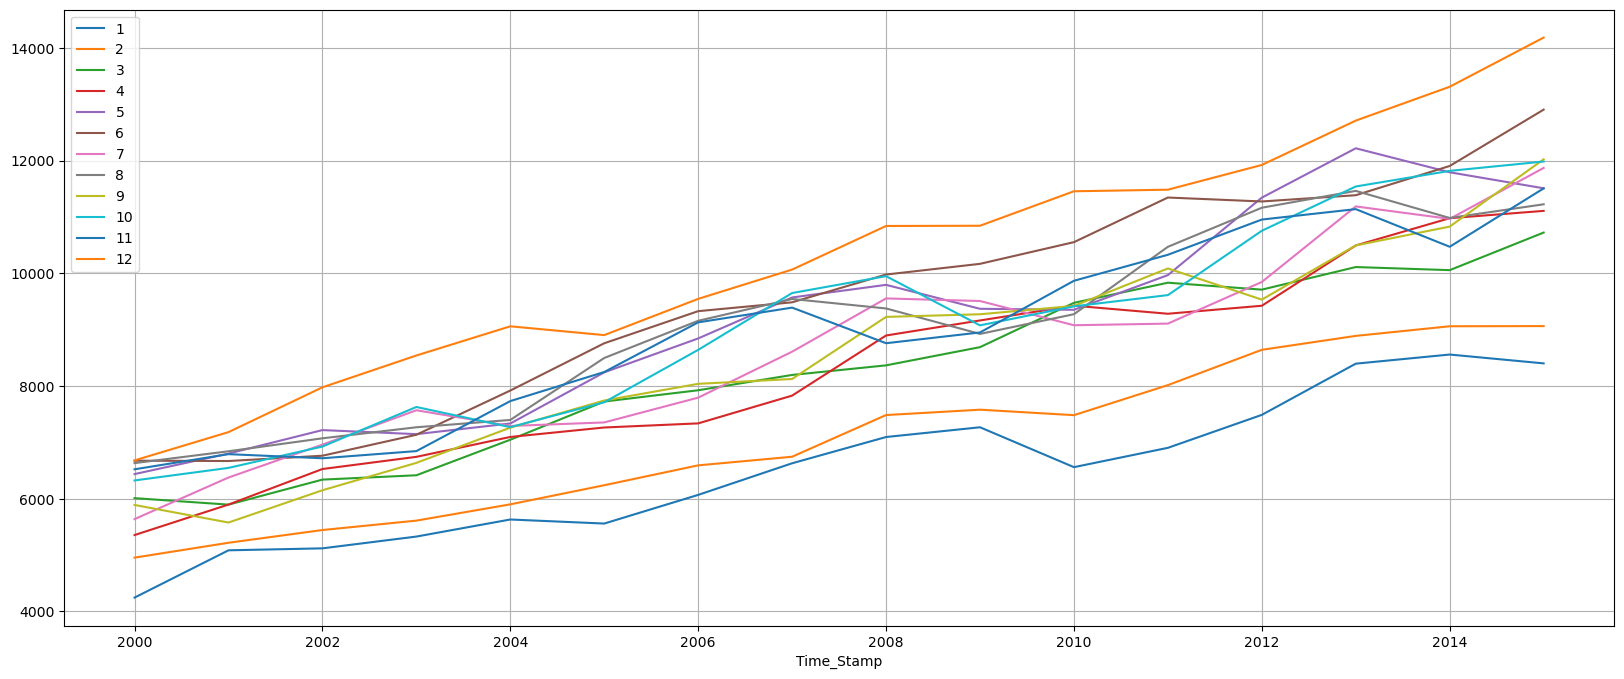

In [56]:
monthly_sales_across_years.plot()
plt.grid()
plt.legend(loc='best');

## Plot the Empirical Cumulative Distribution.

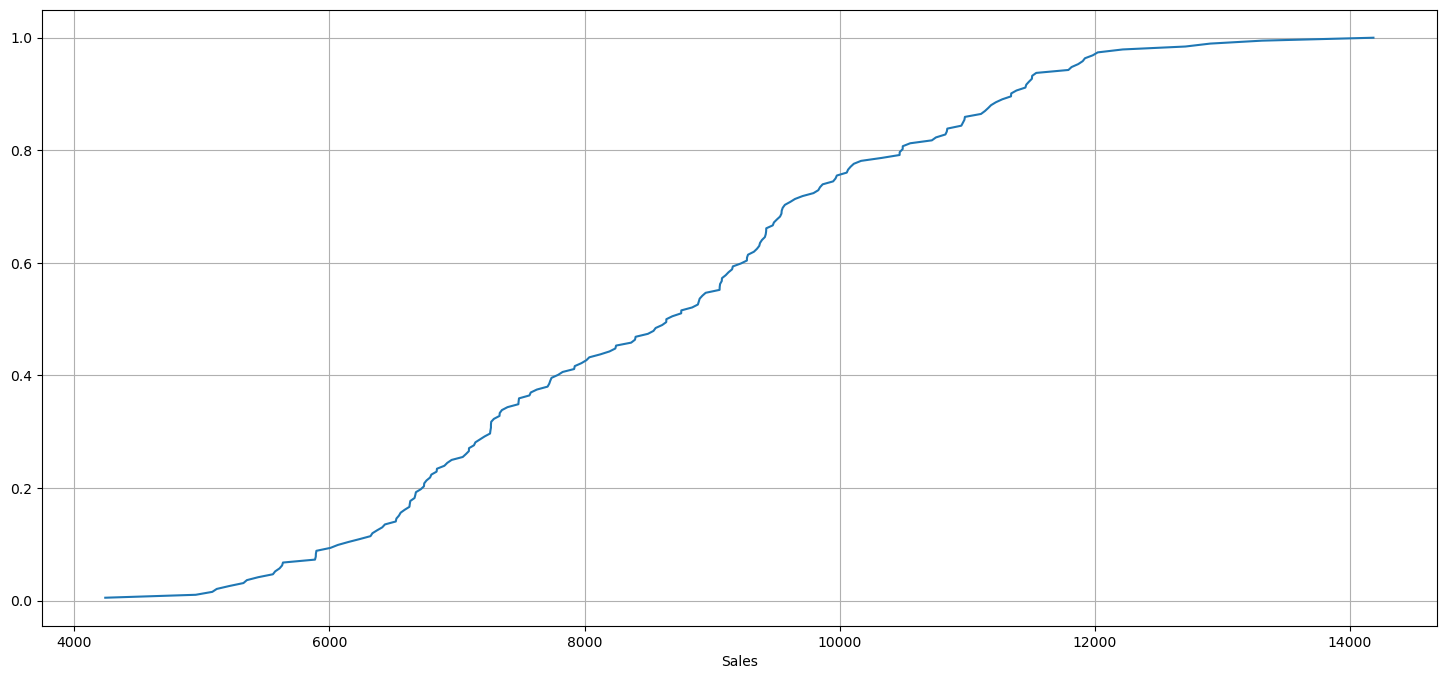

In [59]:
# statistics
from statsmodels.distributions.empirical_distribution import ECDF

plt.figure(figsize = (18, 8))
cdf = ECDF(df['RetailSales'])
plt.plot(cdf.x, cdf.y, label = "statmodels");
plt.grid()
plt.xlabel('Sales');


# Plot the average RetailSales per month and the month on month percentage change of RetailSales.

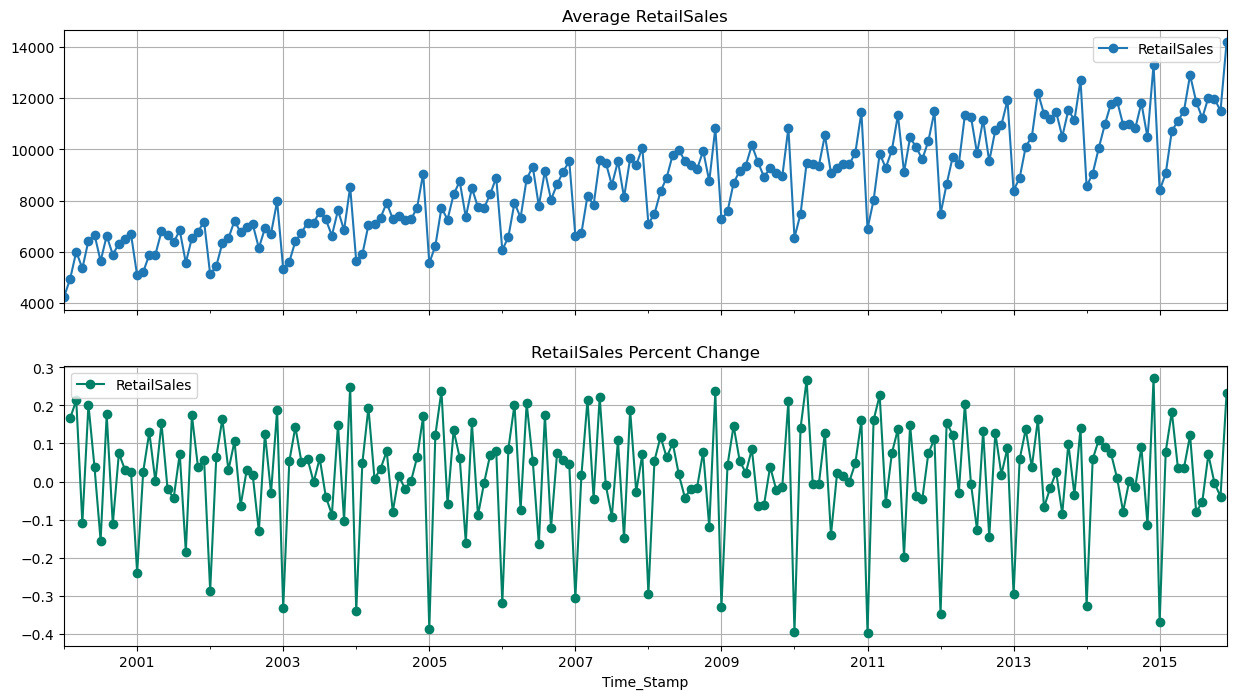

In [62]:
# group by date and get average RetailSales, and precent change
average    = df.groupby(df.index)["RetailSales"].mean()
pct_change = df.groupby(df.index)["RetailSales"].sum().pct_change()

fig, (axis1,axis2) = plt.subplots(2,1,sharex=True,figsize=(15,8))

# plot average RetailSales over time(year-month)
ax1 = average.plot(legend=True,ax=axis1,marker='o',title="Average RetailSales",grid=True)
ax1.set_xticks(range(len(average)))
ax1.set_xticklabels(average.index.tolist())
# plot precent change for RetailSales over time(year-month)
ax2 = pct_change.plot(legend=True,ax=axis2,marker='o',colormap="summer",title="RetailSales Percent Change",grid=True)

## Decompose the Time Series and plot the different components.

In [65]:
from    statsmodels.tsa.seasonal import   seasonal_decompose

In [67]:
from pylab import rcParams
rcParams['figure.figsize'] = 20,8

## Additive Decomposition

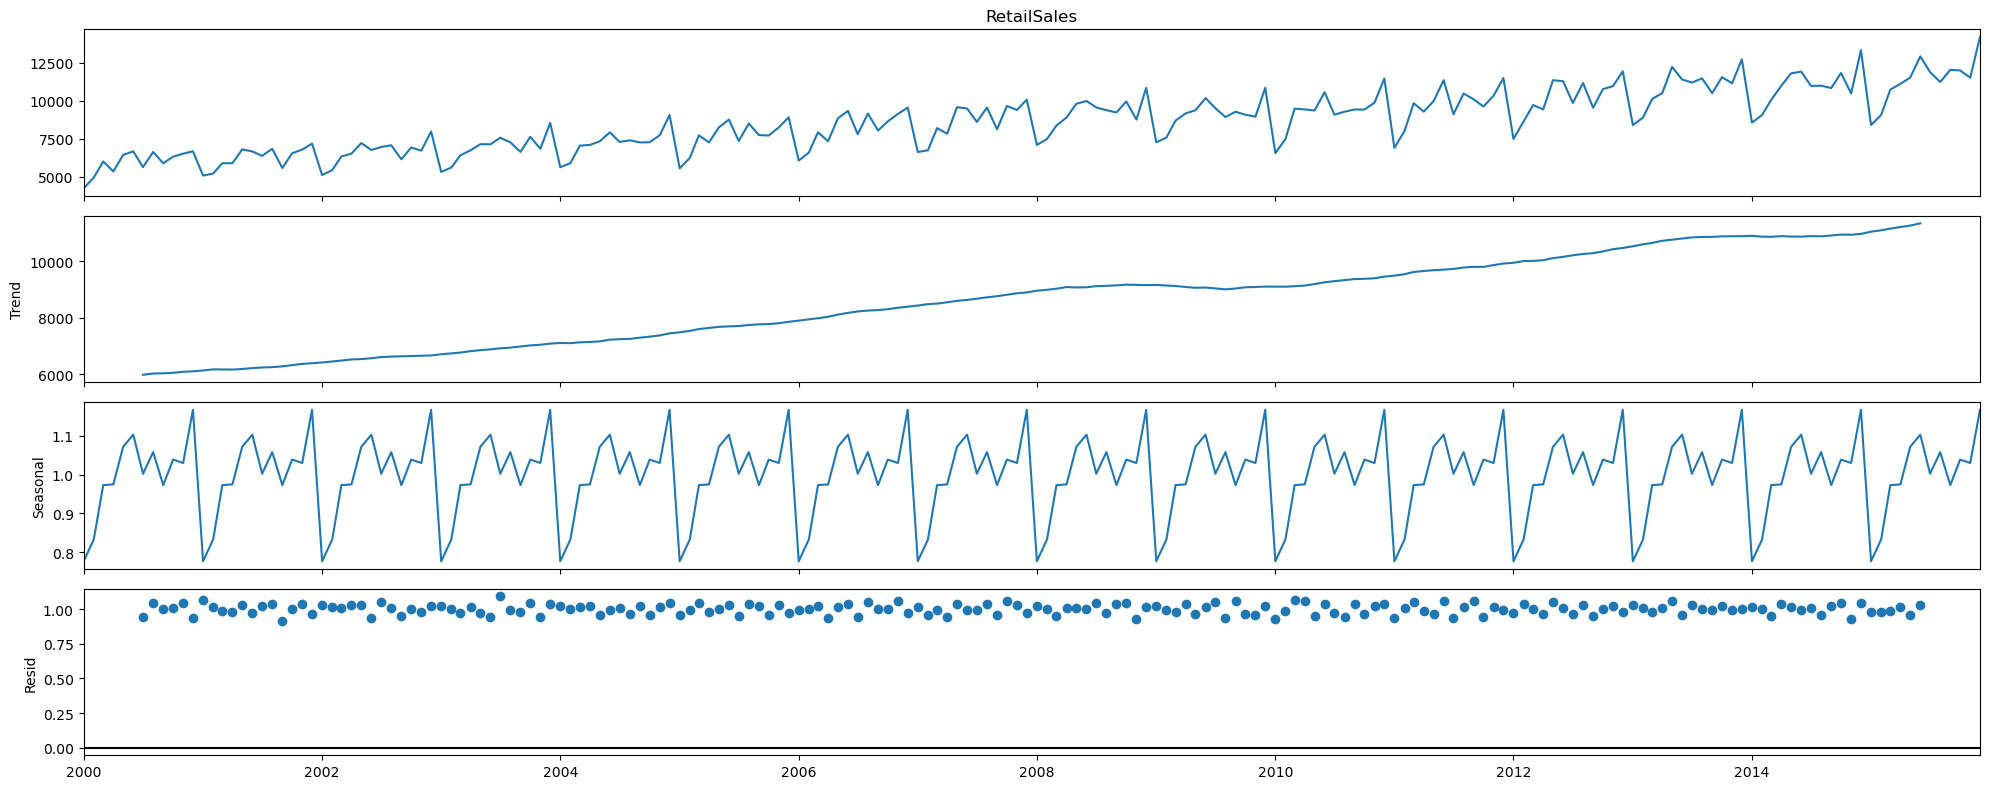

In [70]:
decomposition = seasonal_decompose(df['RetailSales'],model='multiplicative')
decomposition.plot();

In [72]:
trend = decomposition.trend
seasonality = decomposition.seasonal
residual = decomposition.resid

print('Trend','\n',trend.head(12),'\n')
print('Seasonality','\n',seasonality.head(12),'\n')
print('Residual','\n',residual.head(12),'\n')

Trend 
 Time_Stamp
2000-01-01            NaN
2000-02-01            NaN
2000-03-01            NaN
2000-04-01            NaN
2000-05-01            NaN
2000-06-01            NaN
2000-07-01    5979.708333
2000-08-01    6025.666667
2000-09-01    6031.875000
2000-10-01    6049.625000
2000-11-01    6087.333333
2000-12-01    6102.250000
Name: trend, dtype: float64 

Seasonality 
 Time_Stamp
2000-01-01    0.776144
2000-02-01    0.832383
2000-03-01    0.972875
2000-04-01    0.974656
2000-05-01    1.071771
2000-06-01    1.103094
2000-07-01    1.002165
2000-08-01    1.058023
2000-09-01    0.972828
2000-10-01    1.038756
2000-11-01    1.029970
2000-12-01    1.167333
Name: seasonal, dtype: float64 

Residual 
 Time_Stamp
2000-01-01         NaN
2000-02-01         NaN
2000-03-01         NaN
2000-04-01         NaN
2000-05-01         NaN
2000-06-01         NaN
2000-07-01    0.940485
2000-08-01    1.039952
2000-09-01    1.003241
2000-10-01    1.006034
2000-11-01    1.039910
2000-12-01    0.937479
Name: r

## Multiplicative Decomposition

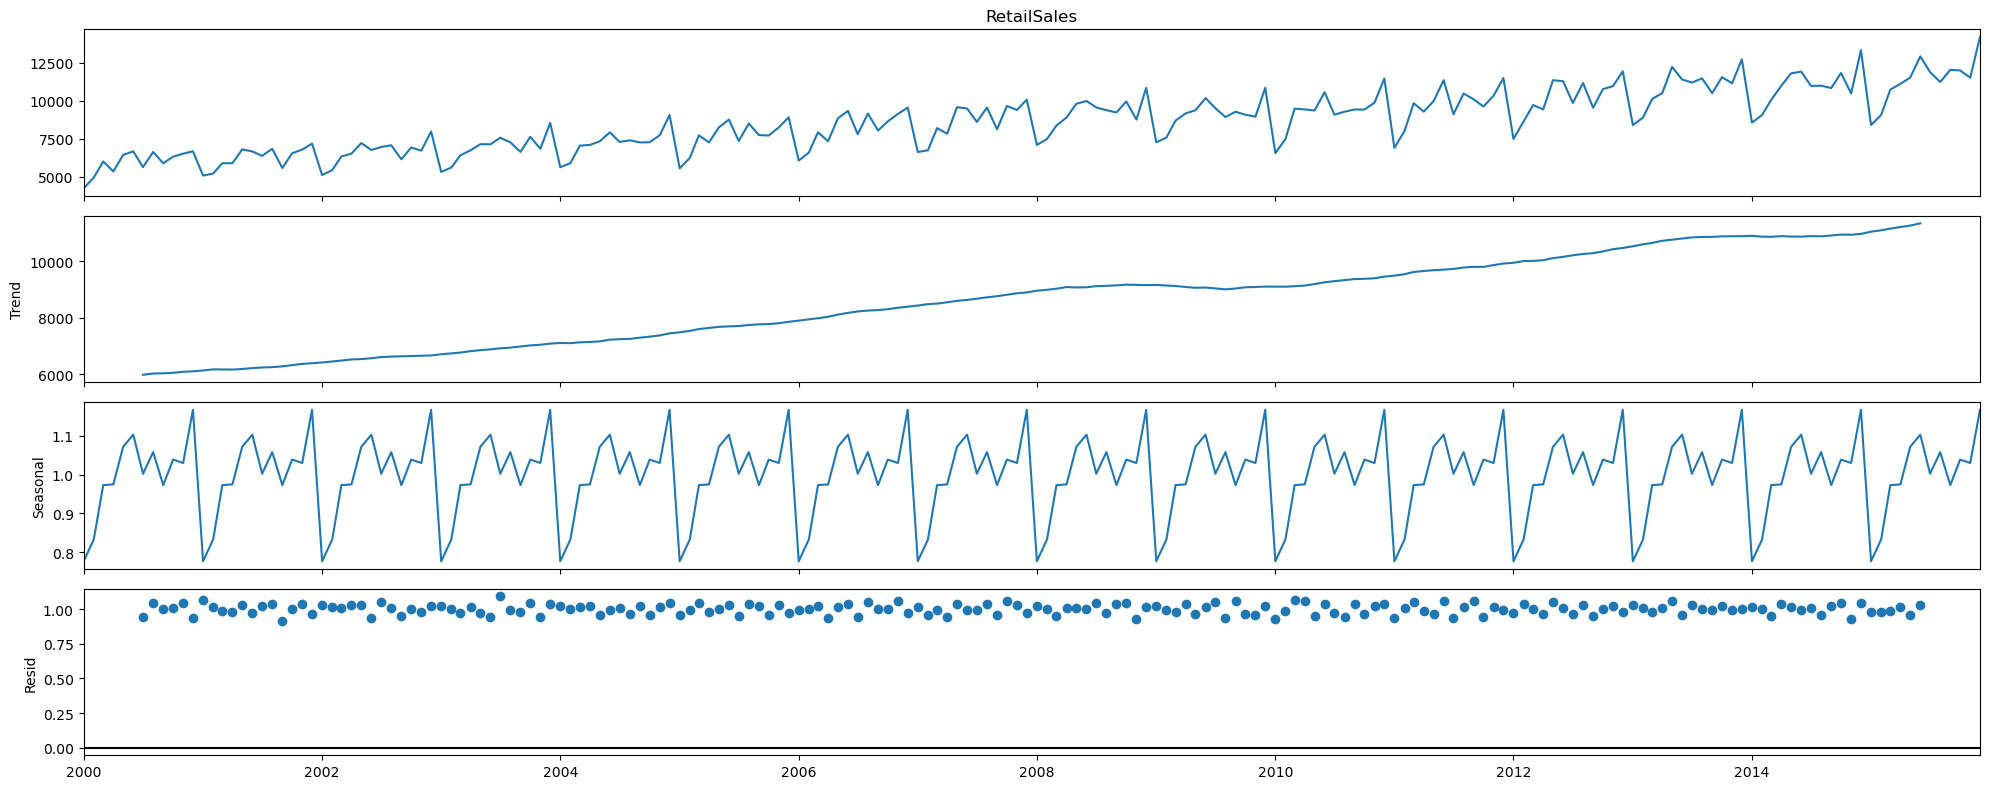

In [75]:
decomposition = seasonal_decompose(df['RetailSales'],model='multiplicative')
decomposition.plot();


In [78]:
trend = decomposition.trend
seasonality = decomposition.seasonal
residual = decomposition.resid

print('Trend','\n',trend.head(12),'\n')
print('Seasonality','\n',seasonality.head(12),'\n')
print('Residual','\n',residual.head(12),'\n')


Trend 
 Time_Stamp
2000-01-01            NaN
2000-02-01            NaN
2000-03-01            NaN
2000-04-01            NaN
2000-05-01            NaN
2000-06-01            NaN
2000-07-01    5979.708333
2000-08-01    6025.666667
2000-09-01    6031.875000
2000-10-01    6049.625000
2000-11-01    6087.333333
2000-12-01    6102.250000
Name: trend, dtype: float64 

Seasonality 
 Time_Stamp
2000-01-01    0.776144
2000-02-01    0.832383
2000-03-01    0.972875
2000-04-01    0.974656
2000-05-01    1.071771
2000-06-01    1.103094
2000-07-01    1.002165
2000-08-01    1.058023
2000-09-01    0.972828
2000-10-01    1.038756
2000-11-01    1.029970
2000-12-01    1.167333
Name: seasonal, dtype: float64 

Residual 
 Time_Stamp
2000-01-01         NaN
2000-02-01         NaN
2000-03-01         NaN
2000-04-01         NaN
2000-05-01         NaN
2000-06-01         NaN
2000-07-01    0.940485
2000-08-01    1.039952
2000-09-01    1.003241
2000-10-01    1.006034
2000-11-01    1.039910
2000-12-01    0.937479
Name: r

In [80]:
data = decomposition.trend*decomposition.resid

<Axes: xlabel='Time_Stamp'>

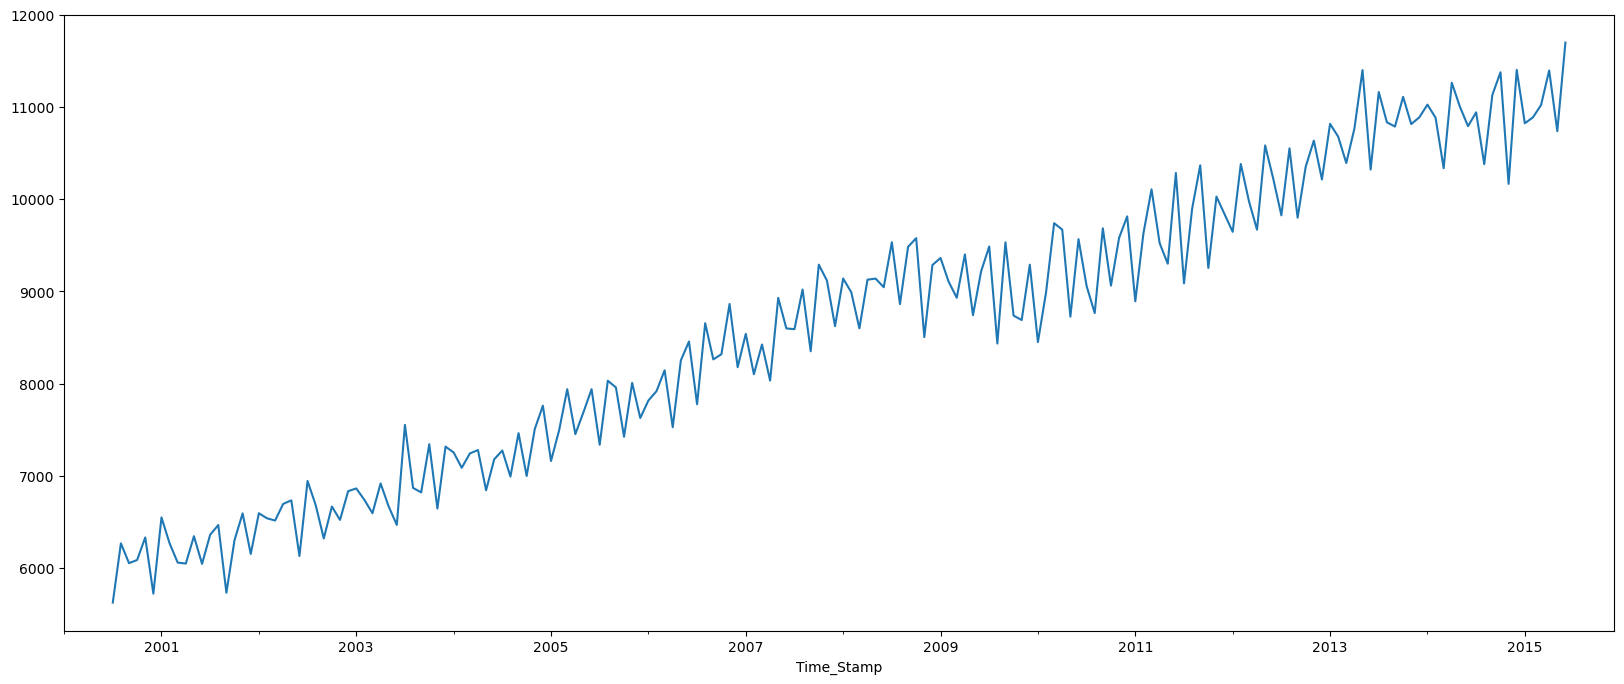

In [82]:
data.plot()

<Axes: xlabel='Time_Stamp'>

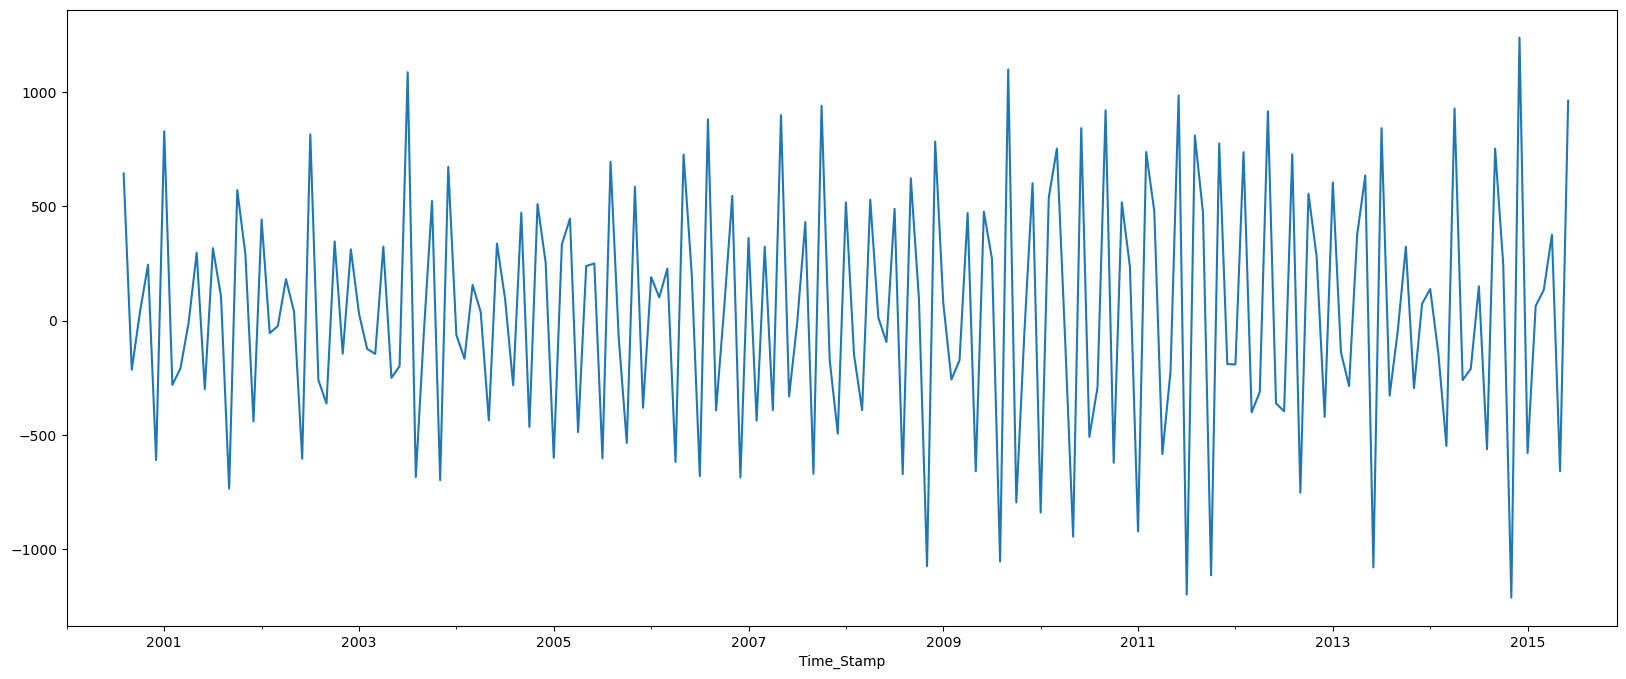

In [84]:
data.diff().plot()

# Check for stationarity of the whole Time Series data.

In [87]:
## Test for stationarity of the series - Dicky Fuller test

from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries):
    
    #Determing rolling statistics
    rolmean = timeseries.rolling(window=12).mean() #determining the rolling mean
    rolstd = timeseries.rolling(window=12).std()   #determining the rolling standard deviation

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)
    
    #Perform Dickey-Fuller test:
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput,'\n')

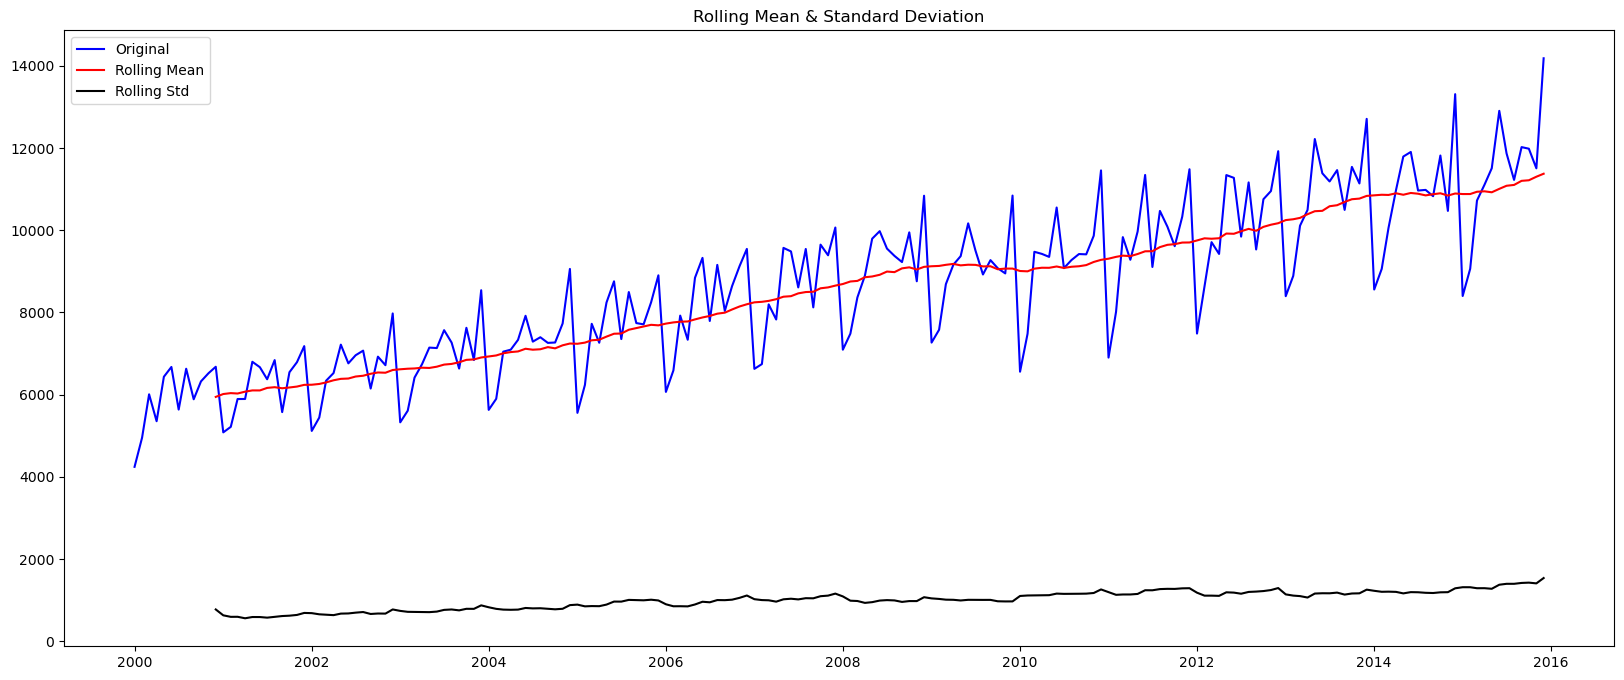

Results of Dickey-Fuller Test:
Test Statistic                   0.151757
p-value                          0.969422
#Lags Used                      14.000000
Number of Observations Used    177.000000
Critical Value (1%)             -3.467845
Critical Value (5%)             -2.878012
Critical Value (10%)            -2.575551
dtype: float64 



In [89]:
test_stationarity(df['RetailSales'])

We see that at 5% significant level the Time Series is non-stationary.

Let us take a difference of order 1 and check whether the Time Series is stationary or not.

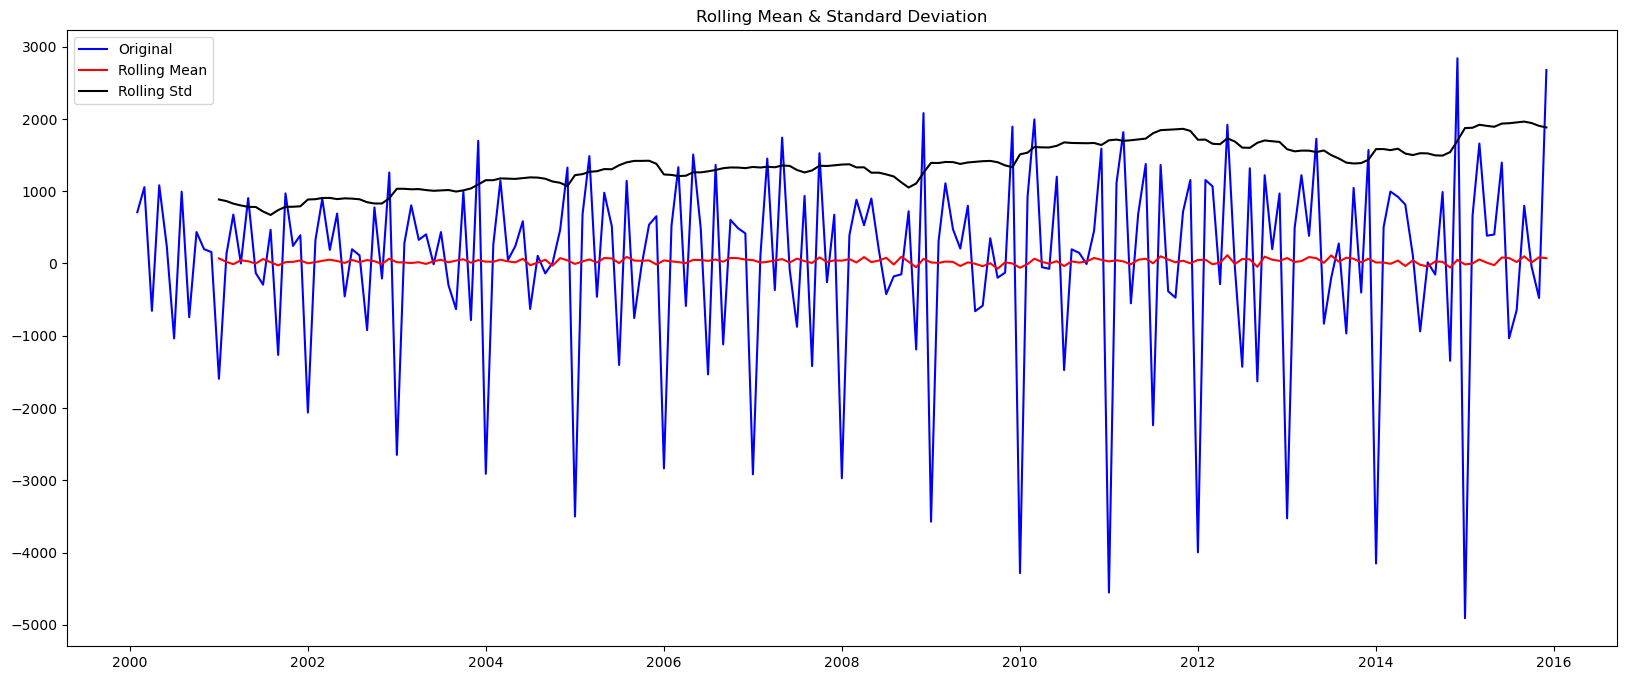

Results of Dickey-Fuller Test:
Test Statistic                  -3.570704
p-value                          0.006346
#Lags Used                      13.000000
Number of Observations Used    177.000000
Critical Value (1%)             -3.467845
Critical Value (5%)             -2.878012
Critical Value (10%)            -2.575551
dtype: float64 



In [92]:
test_stationarity(df['RetailSales'].diff().dropna())

We see that at alpha = 0.05 the Time Series is indeed stationary.

# Plot the Autocorrelation and the Partial Autocorrelation function plots on the whole data.

In [98]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

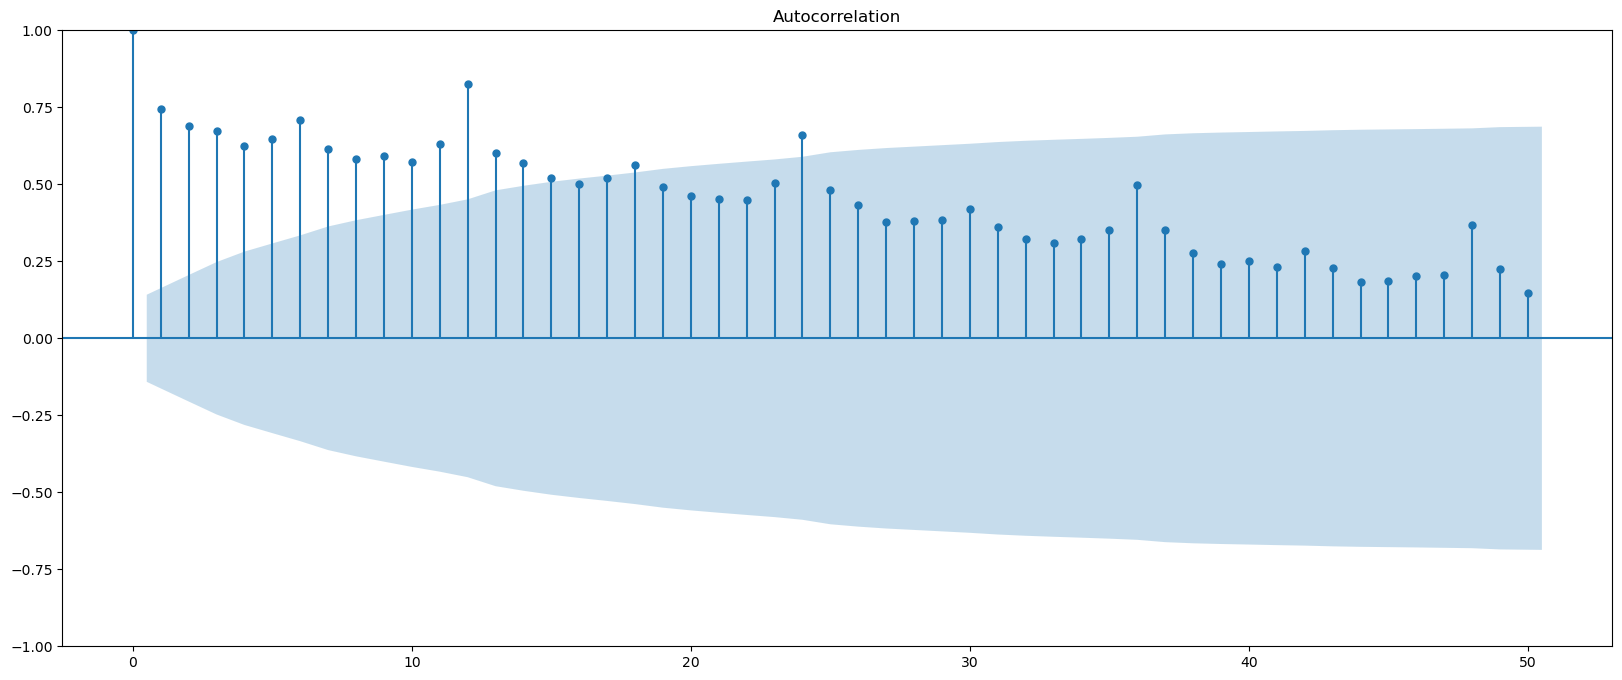

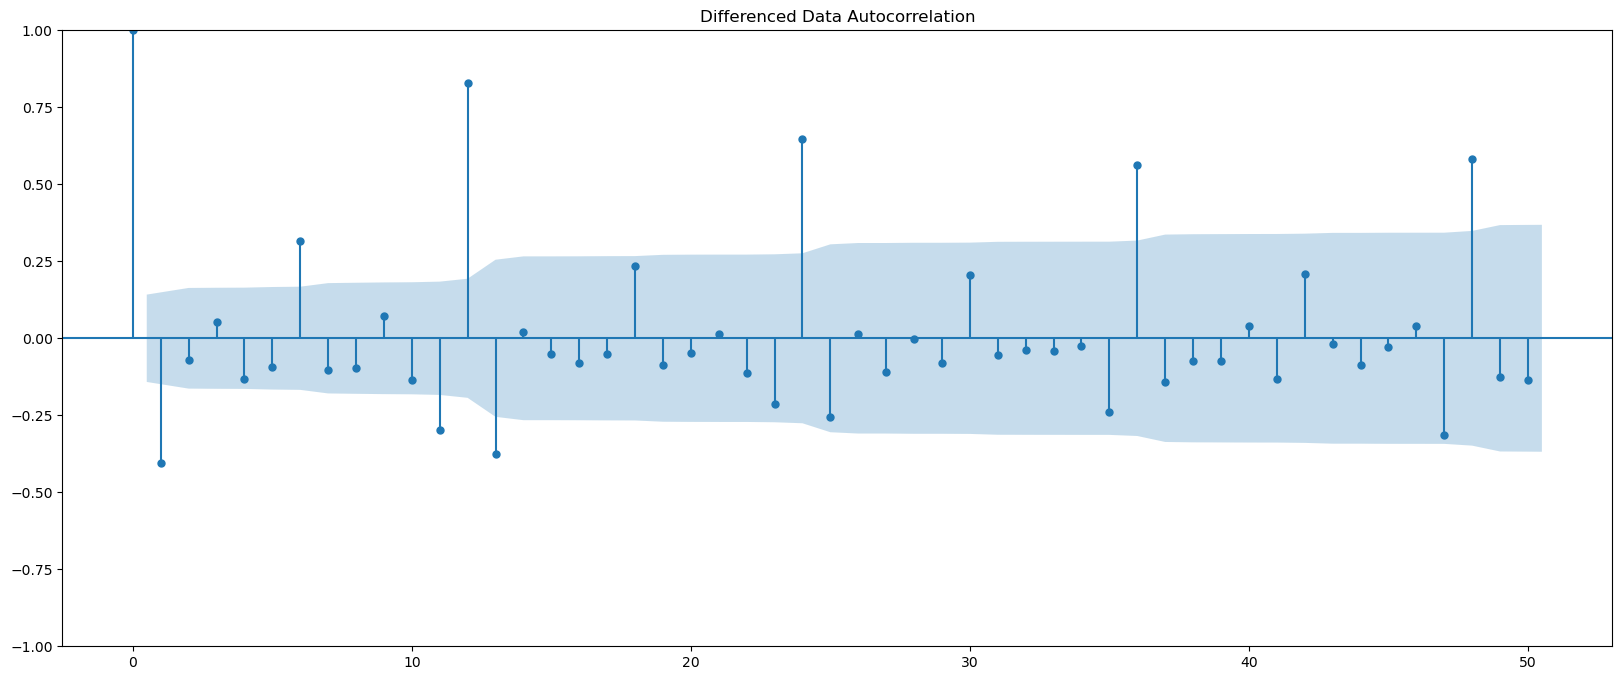

In [100]:
plot_acf(df['RetailSales'],lags=50)
plot_acf(df['RetailSales'].diff().dropna(),lags=50,title='Differenced Data Autocorrelation')
plt.show()


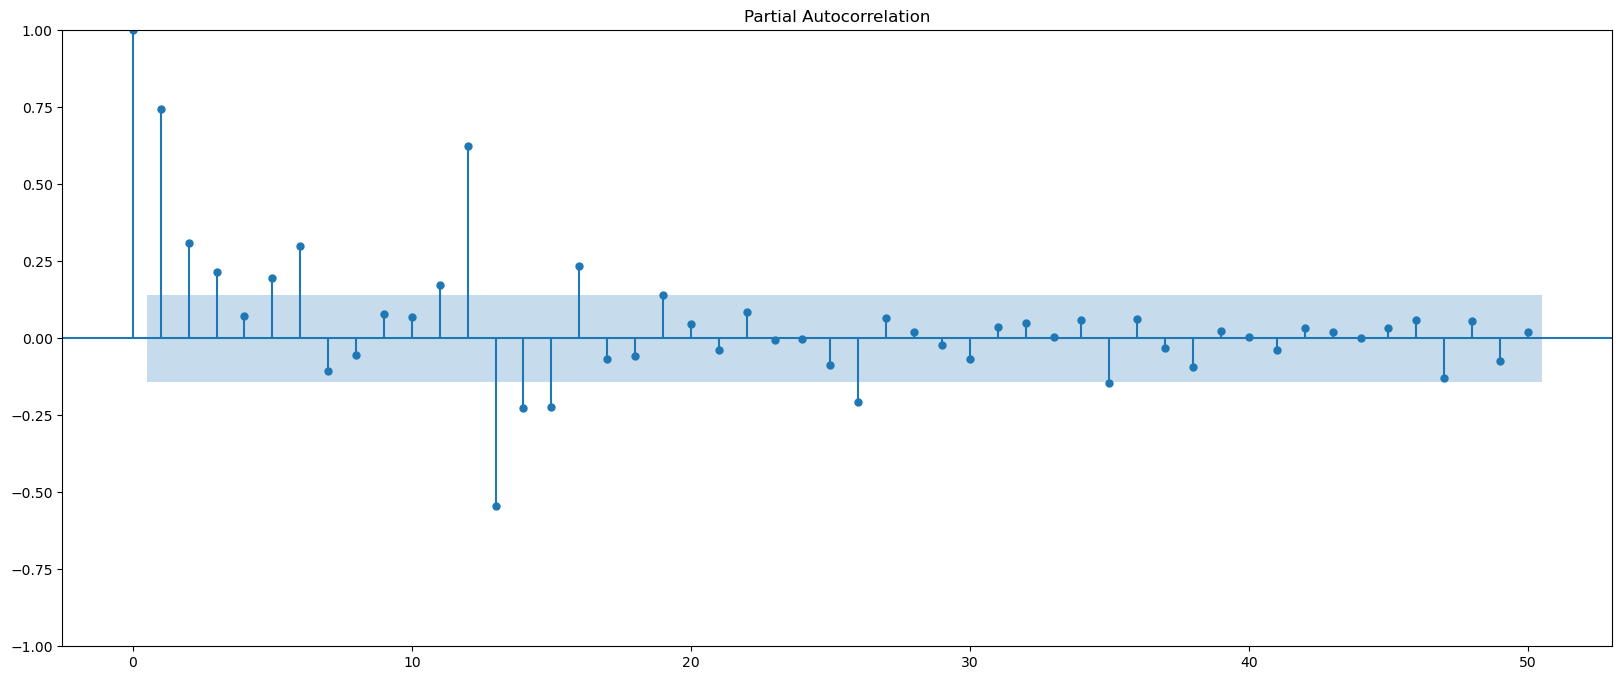

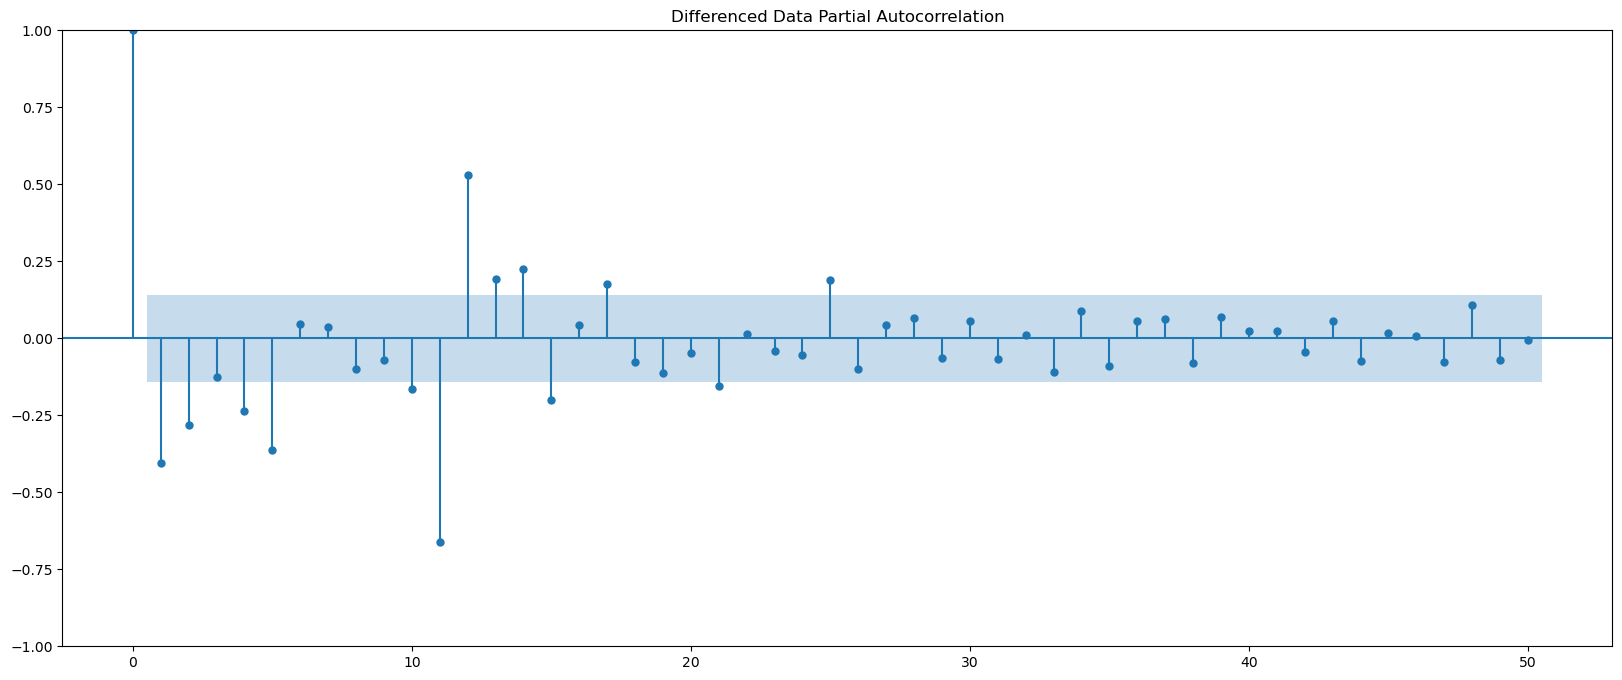

In [102]:
plot_pacf(df['RetailSales'],lags=50)
plot_pacf(df['RetailSales'].diff().dropna(),lags=50,title='Differenced Data Partial Autocorrelation')
plt.show()

From the above plots, we can say that there seems to be a seasonality in the data.

# Split the data into train and test and plot the training and test data.

Training Data is till the end of 2010. Test Data is from the beginning of 2011 to the last time stamp provided.

In [211]:
train=df[df.index.year < 2011]
test=df[df.index.year >= 2011]

In [213]:
train.index = pd.to_datetime(train.index)
train = train.asfreq('MS') 

In [215]:
## This is to display multiple data frames from one cell
from IPython.display import display

In [217]:
print('First few rows of Training Data')
display(train.head())
print('Last few rows of Training Data')
display(train.tail())
print('First few rows of Test Data')
display(test.head())
print('Last few rows of Test Data')
display(test.tail())

First few rows of Training Data


,RetailSales
Time_Stamp,
2000-01-01,4243
2000-02-01,4952
2000-03-01,6008
2000-04-01,5353
2000-05-01,6435


Last few rows of Training Data


,RetailSales
Time_Stamp,
2010-08-01,9273
2010-09-01,9420
2010-10-01,9413
2010-11-01,9866
2010-12-01,11455


First few rows of Test Data


,RetailSales
Time_Stamp,
2011-01-01,6901
2011-02-01,8014
2011-03-01,9832
2011-04-01,9281
2011-05-01,9967


Last few rows of Test Data


,RetailSales
Time_Stamp,
2015-08-01,11224
2015-09-01,12022
2015-10-01,11983
2015-11-01,11506
2015-12-01,14183


In [219]:
print(train.shape)
print(test.shape)

(132, 1)
(60, 1)


# Check for stationarity of the Training Data Time Series.

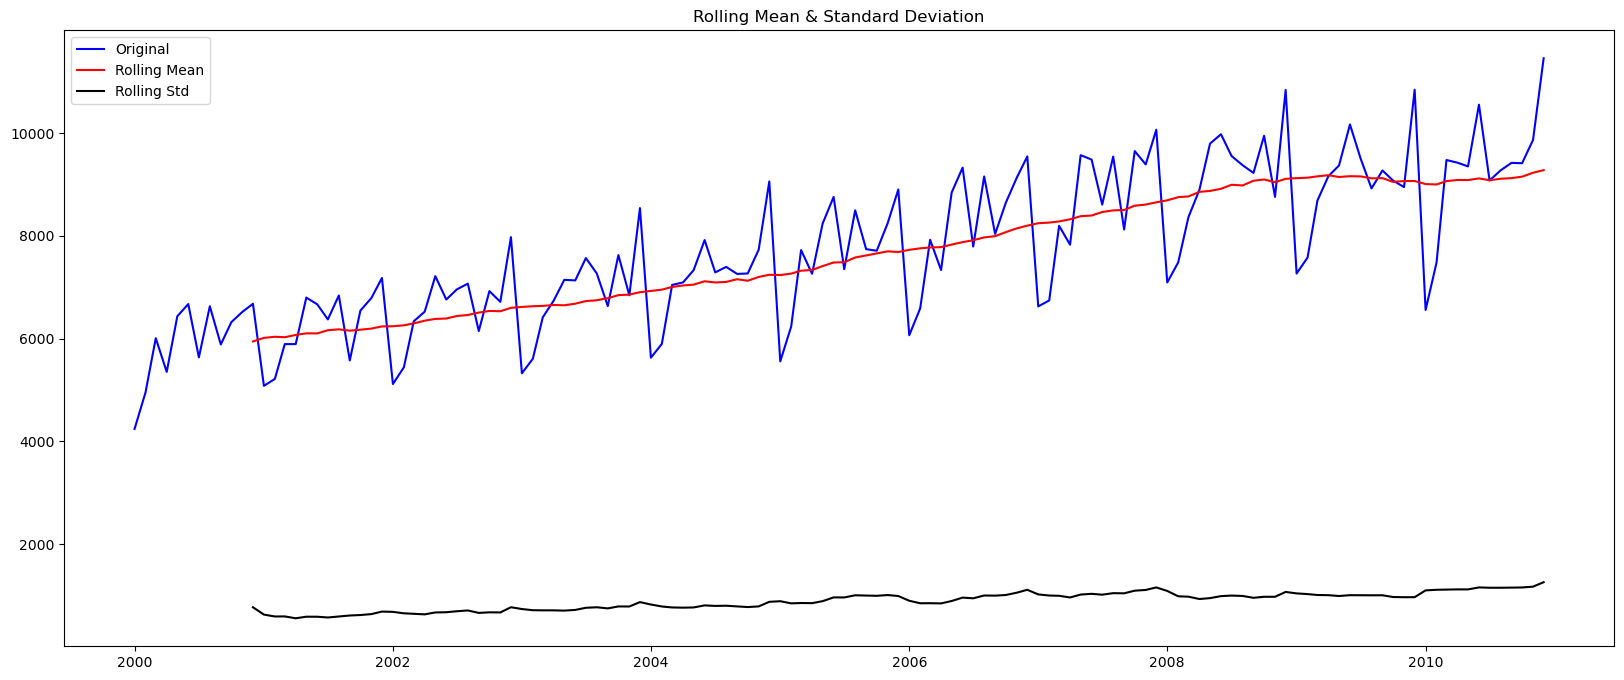

Results of Dickey-Fuller Test:
Test Statistic                  -1.093036
p-value                          0.717841
#Lags Used                      11.000000
Number of Observations Used    120.000000
Critical Value (1%)             -3.486056
Critical Value (5%)             -2.885943
Critical Value (10%)            -2.579785
dtype: float64 



In [222]:
test_stationarity(train['RetailSales'])


We see that the series is not stationary at alpha = 0.05.

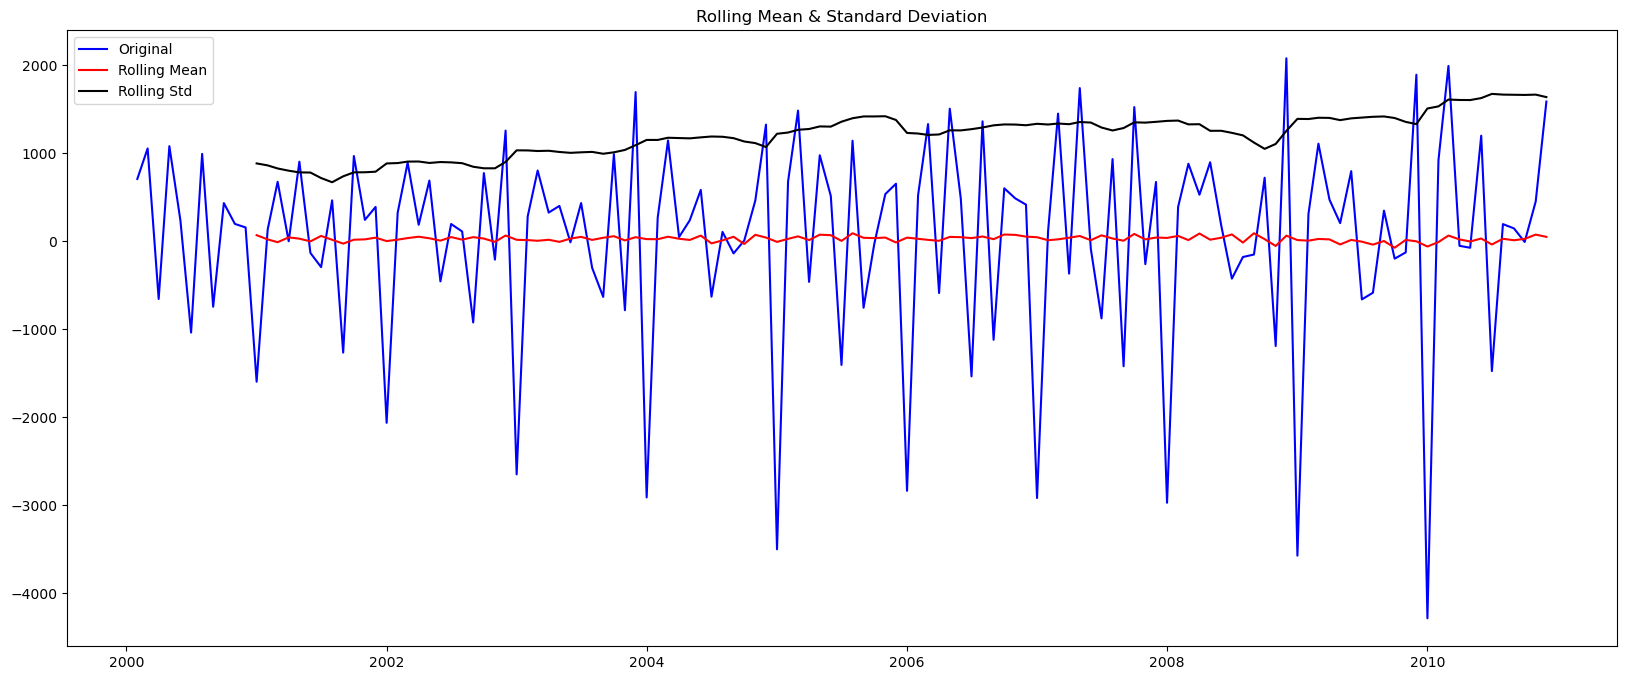

Results of Dickey-Fuller Test:
Test Statistic                  -2.821269
p-value                          0.055299
#Lags Used                      13.000000
Number of Observations Used    117.000000
Critical Value (1%)             -3.487517
Critical Value (5%)             -2.886578
Critical Value (10%)            -2.580124
dtype: float64 



In [225]:
test_stationarity(train['RetailSales'].diff().dropna())

We see that after taking a difference of order 1 the series have become stationary at alpha = 0.05.

Note: If the series is non-stationary, stationarize the Time Series by taking a difference of the Time Series. Then we can use this particular differenced series to train the ARIMA models. We do not need to worry about stationarity for the Test Data because we are not building any models on the Test Data, we are evaluating our models over there. You can look at other kinds of transformations as part of making the time series stationary like taking logarithms.

In [229]:
train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 132 entries, 2000-01-01 to 2010-12-01
Freq: MS
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   RetailSales  132 non-null    int64
dtypes: int64(1)
memory usage: 2.1 KB


# Build an Automated version of an ARIMA model for which the best parameters are selected in accordance with the lowest Akaike Information Criteria (AIC).

Note: The data has some seasonality so ideally we should build a SARIMA model. But for demonstration purposes we are building an ARIMA model both by looking at the minimum AIC criterion and by looking at the ACF and the PACF plots.

In [233]:
## The following loop helps us in getting a combination of different parameters of p and q in the range of 0 and 2
## We have kept the value of d as 1 as we need to take a difference of the series to make it stationary.

import itertools
p = q = range(0, 3)
d= range(1,2)
pdq = list(itertools.product(p, d, q))
print('Some parameter combinations for the Model...')
for i in range(1,len(pdq)):
    print('Model: {}'.format(pdq[i]))

Some parameter combinations for the Model...
Model: (0, 1, 1)
Model: (0, 1, 2)
Model: (1, 1, 0)
Model: (1, 1, 1)
Model: (1, 1, 2)
Model: (2, 1, 0)
Model: (2, 1, 1)
Model: (2, 1, 2)


In [235]:
# Creating an empty Dataframe with column names only
ARIMA_AIC = pd.DataFrame(columns=['param', 'AIC'])
ARIMA_AIC

,param,AIC


In [237]:
from statsmodels.tsa.arima.model import ARIMA  # ← updated path


for param in pdq:
    try:
        model = ARIMA(train['RetailSales'], order=param)
        results = model.fit()
        print(f'ARIMA{param} - AIC: {results.aic}')
        
        # Use concat instead of append
        new_row = pd.DataFrame([{'param': param, 'AIC': results.aic}])
        ARIMA_AIC = pd.concat([ARIMA_AIC, new_row], ignore_index=True)
        
    except Exception as e:
        print(f'ARIMA{param} - Error: {e}')

ARIMA(0, 1, 0) - AIC: 2221.4561490083324
ARIMA(0, 1, 1) - AIC: 2181.332848535213


C:\Users\Dell\AppData\Local\Temp\ipykernel_9432\2938872842.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  ARIMA_AIC = pd.concat([ARIMA_AIC, new_row], ignore_index=True)


ARIMA(0, 1, 2) - AIC: 2179.814006976092
ARIMA(1, 1, 0) - AIC: 2203.190440111526
ARIMA(1, 1, 1) - AIC: 2179.8928433530555
ARIMA(1, 1, 2) - AIC: 2181.7986610611297
ARIMA(2, 1, 0) - AIC: 2196.4953768917158
ARIMA(2, 1, 1) - AIC: 2181.770530585267
ARIMA(2, 1, 2) - AIC: 2183.7868862382184


C:\Users\Dell\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [239]:
## Sort the above AIC values in the ascending order to get the parameters for the minimum AIC value

ARIMA_AIC.sort_values(by='AIC',ascending=True)

,param,AIC
2,"(0, 1, 2)",2179.814007
4,"(1, 1, 1)",2179.892843
1,"(0, 1, 1)",2181.332849
7,"(2, 1, 1)",2181.770531
5,"(1, 1, 2)",2181.798661
8,"(2, 1, 2)",2183.786886
6,"(2, 1, 0)",2196.495377
3,"(1, 1, 0)",2203.190440
0,"(0, 1, 0)",2221.456149


In [243]:
auto_ARIMA = ARIMA(train['RetailSales'], order=(2,1,1),freq='MS')

results_auto_ARIMA = auto_ARIMA.fit()

print(results_auto_ARIMA.summary())

                               SARIMAX Results                                
Dep. Variable:            RetailSales   No. Observations:                  132
Model:                 ARIMA(2, 1, 1)   Log Likelihood               -1086.885
Date:                Fri, 30 May 2025   AIC                           2181.771
Time:                        16:42:13   BIC                           2193.271
Sample:                    01-01-2000   HQIC                          2186.444
                         - 12-01-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1820      0.137      1.331      0.183      -0.086       0.450
ar.L2         -0.0332      0.150     -0.222      0.824      -0.327       0.261
ma.L1         -0.8554      0.087     -9.788      0.0

# Predict on the Test Set using this model and evaluate the model.

In [252]:
predicted_auto_ARIMA = results_auto_ARIMA.forecast(steps=len(test))

In [256]:
from sklearn.metrics import  mean_squared_error
rmse = mean_squared_error(test['RetailSales'],predicted_auto_ARIMA,squared=False)
print(rmse)

1674.7069409909116


C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [258]:
resultsDf = pd.DataFrame({'RMSE': [rmse]}
                           ,index=['ARIMA(2,1,1)'])

resultsDf


,RMSE
"ARIMA(2,1,1)",1674.706941


# Build a version of the ARIMA model for which the best parameters are selected by looking at the ACF and the PACF plots.

Let us look at the ACF and the PACF plots once more.

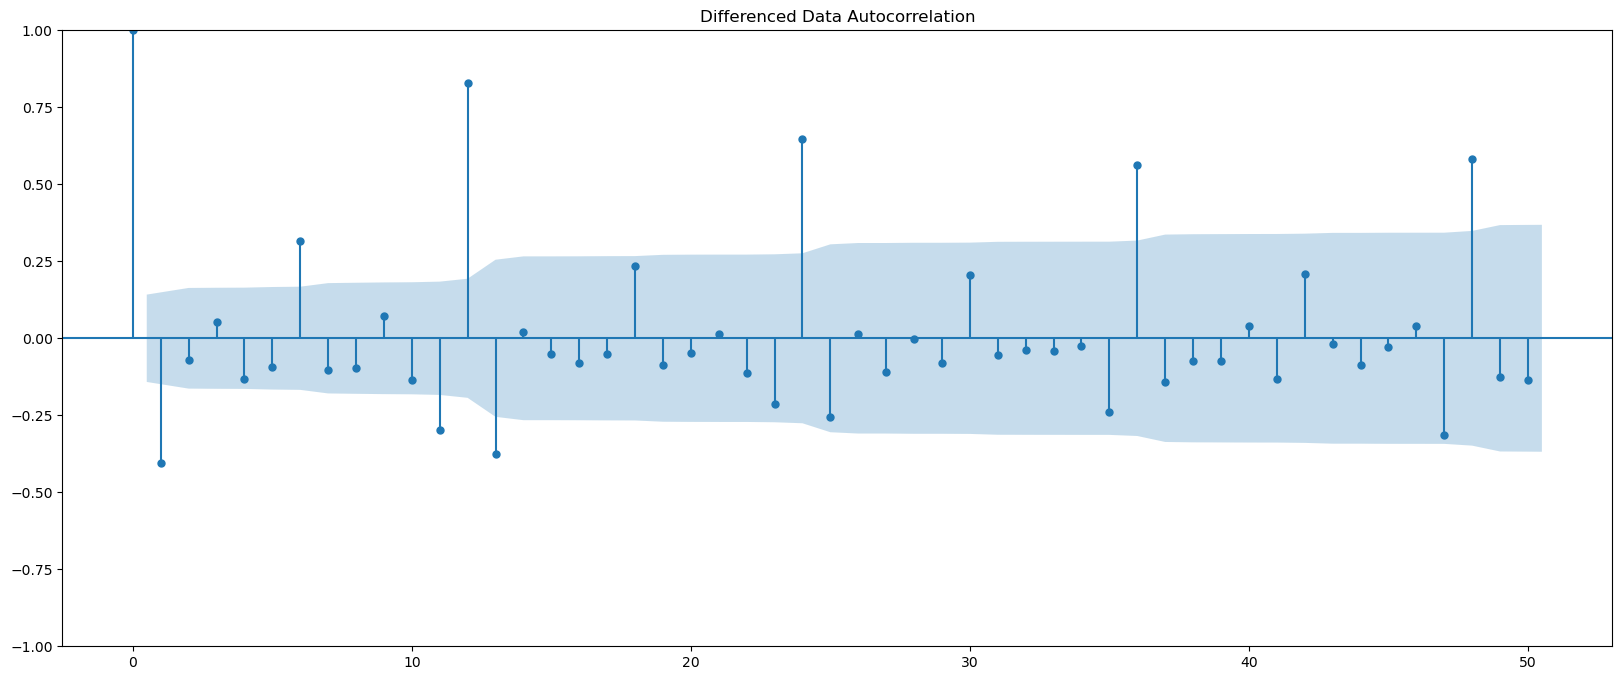

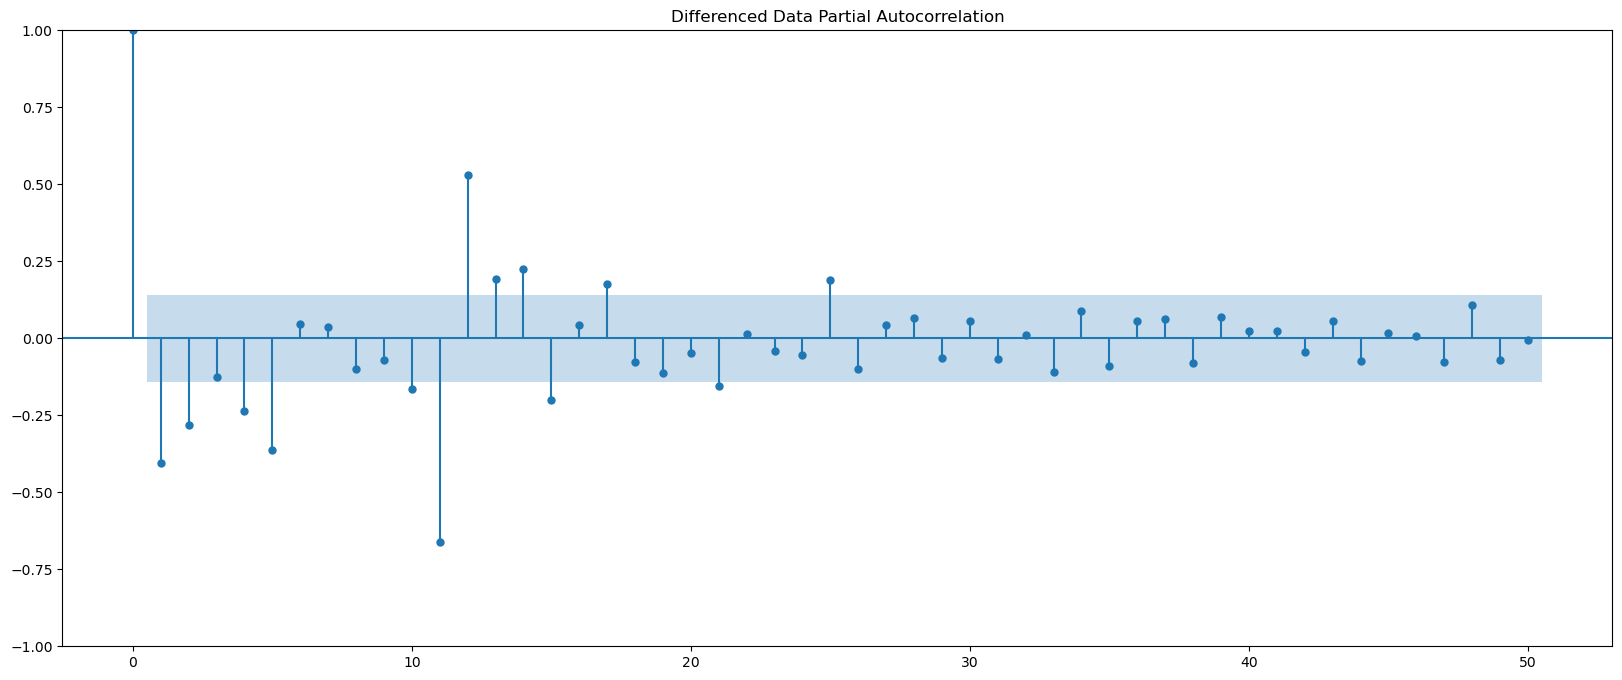

In [262]:
plot_acf(df['RetailSales'].diff().dropna(),lags=50,title='Differenced Data Autocorrelation')
plot_pacf(df['RetailSales'].diff().dropna(),lags=50,title='Differenced Data Partial Autocorrelation')
plt.show()

Here, we have taken alpha=0.05.

The Auto-Regressive parameter in an ARIMA model is 'p' which comes from the significant lag before which the PACF plot cuts-off to 0.
The Moving-Average parameter in an ARIMA model is 'q' which comes from the significant lag before the ACF plot cuts-off to 0. 

By looking at the above plots, we can say that both the PACF and ACF plot cuts-off at lag 0.

In [268]:
manual_ARIMA = ARIMA(train['RetailSales'].astype('float64'), order=(0,1,2),freq='MS')

results_manual_ARIMA = manual_ARIMA.fit()

print(results_manual_ARIMA.summary())

                               SARIMAX Results                                
Dep. Variable:            RetailSales   No. Observations:                  132
Model:                 ARIMA(0, 1, 2)   Log Likelihood               -1086.907
Date:                Fri, 30 May 2025   AIC                           2179.814
Time:                        16:53:24   BIC                           2188.440
Sample:                    01-01-2000   HQIC                          2183.319
                         - 12-01-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.6740      0.088     -7.642      0.000      -0.847      -0.501
ma.L2         -0.1556      0.093     -1.672      0.094      -0.338       0.027
sigma2      9.169e+05   1.35e+05      6.815      0.0

We get a comparatively simpler model by looking at the ACF and the PACF plots.

Note: When we see that both the AR(p) and the MA(q) model are of order 0, we have to convert the input variable into a 'float64' type variable else Python might throw an error.

# Predict on the Test Set using this model and evaluate the model.

In [273]:
predicted_manual_ARIMA = results_manual_ARIMA.forecast(steps=len(test))

In [277]:
rmse = mean_squared_error(test['RetailSales'],predicted_manual_ARIMA,squared=False)
print(rmse)

1673.985990648202


C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [279]:
temp_resultsDf = pd.DataFrame({'RMSE': [rmse]}
                           ,index=['ARIMA(0,1,2)'])


resultsDf = pd.concat([resultsDf,temp_resultsDf])

resultsDf

,RMSE
"ARIMA(2,1,1)",1674.706941
"ARIMA(0,1,2)",1673.985991


We see that there is difference in the RMSE values for both the models, but remember that the second model is a much simpler model.

# Build an Automated version of a SARIMA model for which the best parameters are selected in accordance with the lowest Akaike Information Criteria (AIC).

Let us look at the ACF plot once more to understand the seasonal parameter for the SARIMA model.

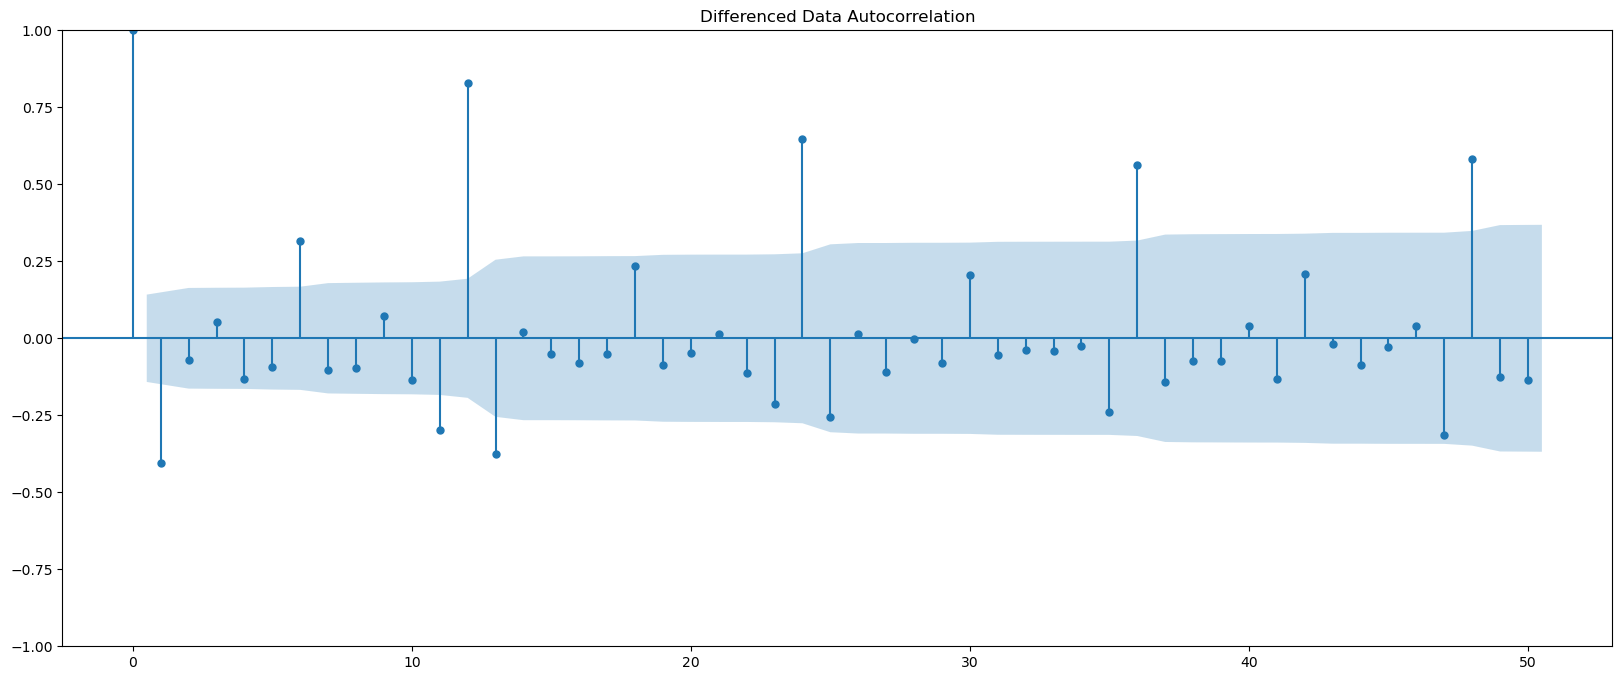

In [284]:
plot_acf(df['RetailSales'].diff().dropna(),lags=50,title='Differenced Data Autocorrelation')
plt.show()

We see that there can be a seasonality of 12. We will run our auto SARIMA models by setting seasonality 12.

## Setting the seasonality as 12 for the first iteration of the auto SARIMA model.

In [289]:
import itertools
p = q = range(0, 3)
d= range(1,2)
D = range(0,1)
pdq = list(itertools.product(p, d, q))
model_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, D, q))]
print('Examples of some parameter combinations for Model...')
for i in range(1,len(pdq)):
    print('Model: {}{}'.format(pdq[i], model_pdq[i]))

Examples of some parameter combinations for Model...
Model: (0, 1, 1)(0, 0, 1, 12)
Model: (0, 1, 2)(0, 0, 2, 12)
Model: (1, 1, 0)(1, 0, 0, 12)
Model: (1, 1, 1)(1, 0, 1, 12)
Model: (1, 1, 2)(1, 0, 2, 12)
Model: (2, 1, 0)(2, 0, 0, 12)
Model: (2, 1, 1)(2, 0, 1, 12)
Model: (2, 1, 2)(2, 0, 2, 12)


In [291]:
SARIMA_AIC = pd.DataFrame(columns=['param','seasonal', 'AIC'])
SARIMA_AIC


,param,seasonal,AIC


In [295]:
import statsmodels.api as sm

# Loop through all combinations
for param in pdq:
    for param_seasonal in model_pdq:
        SARIMA_model = sm.tsa.statespace.SARIMAX(
            train['RetailSales'].values,
            order=param,
            seasonal_order=param_seasonal,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        results_SARIMA = SARIMA_model.fit(maxiter=1000)
        print(f'SARIMA{param}x{param_seasonal} - AIC:{results_SARIMA.aic}')
        
        # Use concat instead of append
        new_row = pd.DataFrame([{
            'param': param,
            'seasonal': param_seasonal,
            'AIC': results_SARIMA.aic
        }])
        SARIMA_AIC = pd.concat([SARIMA_AIC, new_row], ignore_index=True)


SARIMA(0, 1, 0)x(0, 0, 0, 12) - AIC:2205.1393634392834
SARIMA(0, 1, 0)x(0, 0, 1, 12) - AIC:1905.9024332554302


C:\Users\Dell\AppData\Local\Temp\ipykernel_9432\2551314726.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  SARIMA_AIC = pd.concat([SARIMA_AIC, new_row], ignore_index=True)


SARIMA(0, 1, 0)x(0, 0, 2, 12) - AIC:1673.4937134442591
SARIMA(0, 1, 0)x(1, 0, 0, 12) - AIC:1840.023742817042
SARIMA(0, 1, 0)x(1, 0, 1, 12) - AIC:1816.4513149687764
SARIMA(0, 1, 0)x(1, 0, 2, 12) - AIC:1626.4731982133346
SARIMA(0, 1, 0)x(2, 0, 0, 12) - AIC:1653.678741862996
SARIMA(0, 1, 0)x(2, 0, 1, 12) - AIC:1660.971916319716
SARIMA(0, 1, 0)x(2, 0, 2, 12) - AIC:1625.6390864118289
SARIMA(0, 1, 1)x(0, 0, 0, 12) - AIC:2137.6972798824554
SARIMA(0, 1, 1)x(0, 0, 1, 12) - AIC:1843.4187807165301
SARIMA(0, 1, 1)x(0, 0, 2, 12) - AIC:1614.1525744357439
SARIMA(0, 1, 1)x(1, 0, 0, 12) - AIC:1765.7347316765201
SARIMA(0, 1, 1)x(1, 0, 1, 12) - AIC:1725.0338773509802
SARIMA(0, 1, 1)x(1, 0, 2, 12) - AIC:1539.0914129527057
SARIMA(0, 1, 1)x(2, 0, 0, 12) - AIC:1582.813610948673
SARIMA(0, 1, 1)x(2, 0, 1, 12) - AIC:1581.8283796726614
SARIMA(0, 1, 1)x(2, 0, 2, 12) - AIC:1539.972320447351
SARIMA(0, 1, 2)x(0, 0, 0, 12) - AIC:2121.082914113357
SARIMA(0, 1, 2)x(0, 0, 1, 12) - AIC:1829.1432693308439
SARIMA(0, 1, 2)x

In [297]:
SARIMA_AIC.sort_values(by=['AIC']).head()

,param,seasonal,AIC
77,"(2, 1, 2)","(1, 0, 2, 12)",1504.300641
80,"(2, 1, 2)","(2, 0, 2, 12)",1506.260896
23,"(0, 1, 2)","(1, 0, 2, 12)",1518.862707
26,"(0, 1, 2)","(2, 0, 2, 12)",1520.521438
62,"(2, 1, 0)","(2, 0, 2, 12)",1521.879883


In [314]:
import statsmodels.api as sm

auto_SARIMA_12 = sm.tsa.statespace.SARIMAX(train['RetailSales'].values,
                                order=(1, 1, 2),
                                seasonal_order=(2, 0, 2, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
results_auto_SARIMA_12 = auto_SARIMA_6.fit(maxiter=1000)
print(results_auto_SARIMA_12.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  132
Model:             SARIMAX(1, 1, 2)x(2, 0, 2, 12)   Log Likelihood                -753.044
Date:                            Fri, 30 May 2025   AIC                           1522.088
Time:                                    19:01:31   BIC                           1543.243
Sample:                                         0   HQIC                          1530.658
                                            - 132                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1367      0.408     -0.335      0.737      -0.936       0.662
ma.L1         -0.9539      0.374   

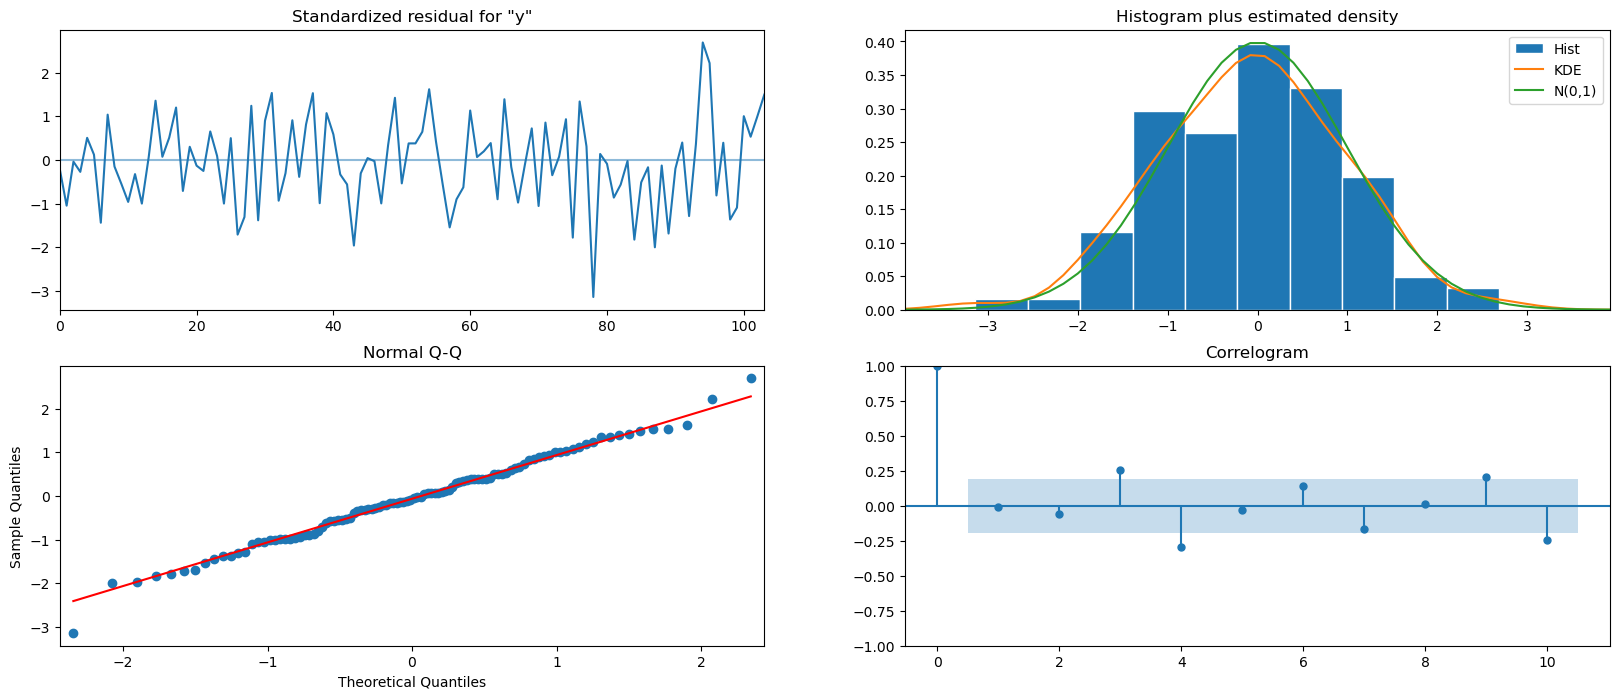

In [316]:
results_auto_SARIMA_12.plot_diagnostics()
plt.show()

From the model diagnostics plot, we can see that all the individual diagnostics plots almost follow the theoretical numbers and thus we cannot develop any pattern from these plots.

# Predict on the Test Set using this model and evaluate the model.

In [318]:
predicted_auto_SARIMA_12 = results_auto_SARIMA_12.get_forecast(steps=len(test))

In [320]:
predicted_auto_SARIMA_12.summary_frame(alpha=0.05).head()

y,mean,mean_se,mean_ci_lower,mean_ci_upper
0,6934.065963,320.224442,6306.437591,7561.694336
1,7959.746665,321.474583,7329.668061,8589.825269
2,9817.617993,332.431508,9166.064209,10469.171777
3,9745.411238,339.839052,9079.338936,10411.483540
4,10226.310786,347.714251,9544.803377,10907.818196


In [322]:
rmse = mean_squared_error(test['RetailSales'],predicted_auto_SARIMA_12.predicted_mean,squared=False)
print(rmse)

576.1868633516941


C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [324]:
temp_resultsDf = pd.DataFrame({'RMSE': [rmse]}
                           ,index=['SARIMA(1,1,2)(2,0,2,12)'])


resultsDf = pd.concat([resultsDf,temp_resultsDf])

resultsDf

,RMSE
"ARIMA(2,1,1)",1674.706941
"ARIMA(0,1,2)",1673.985991
"SARIMA(1,1,2)(2,0,2,12)",576.186863


We see that we have huge gain the RMSE value by including the seasonal parameters as well.

# Build a version of the SARIMA model for which the best parameters are selected by looking at the ACF and the PACF plots. - Seasonality at 12.

Let us look at the ACF and the PACF plots once more.

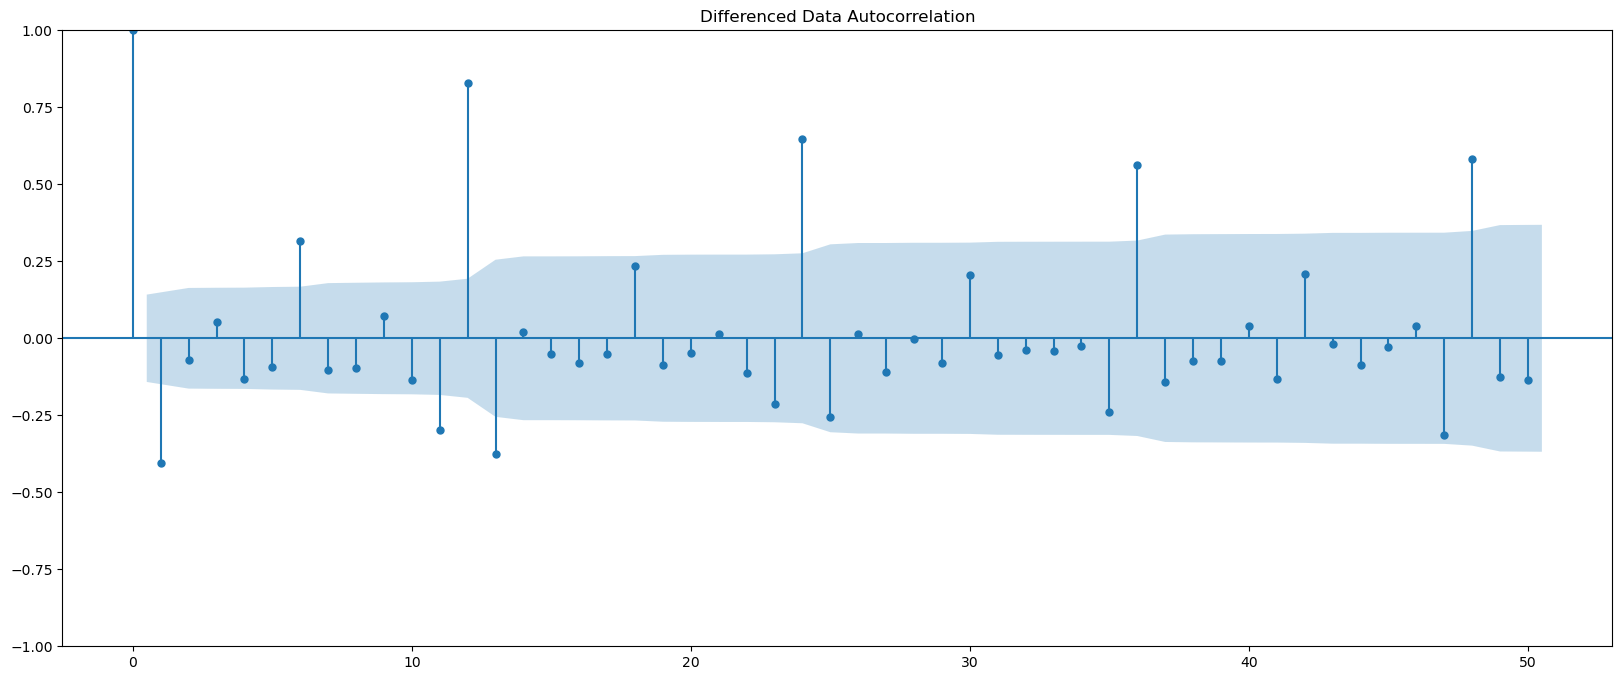

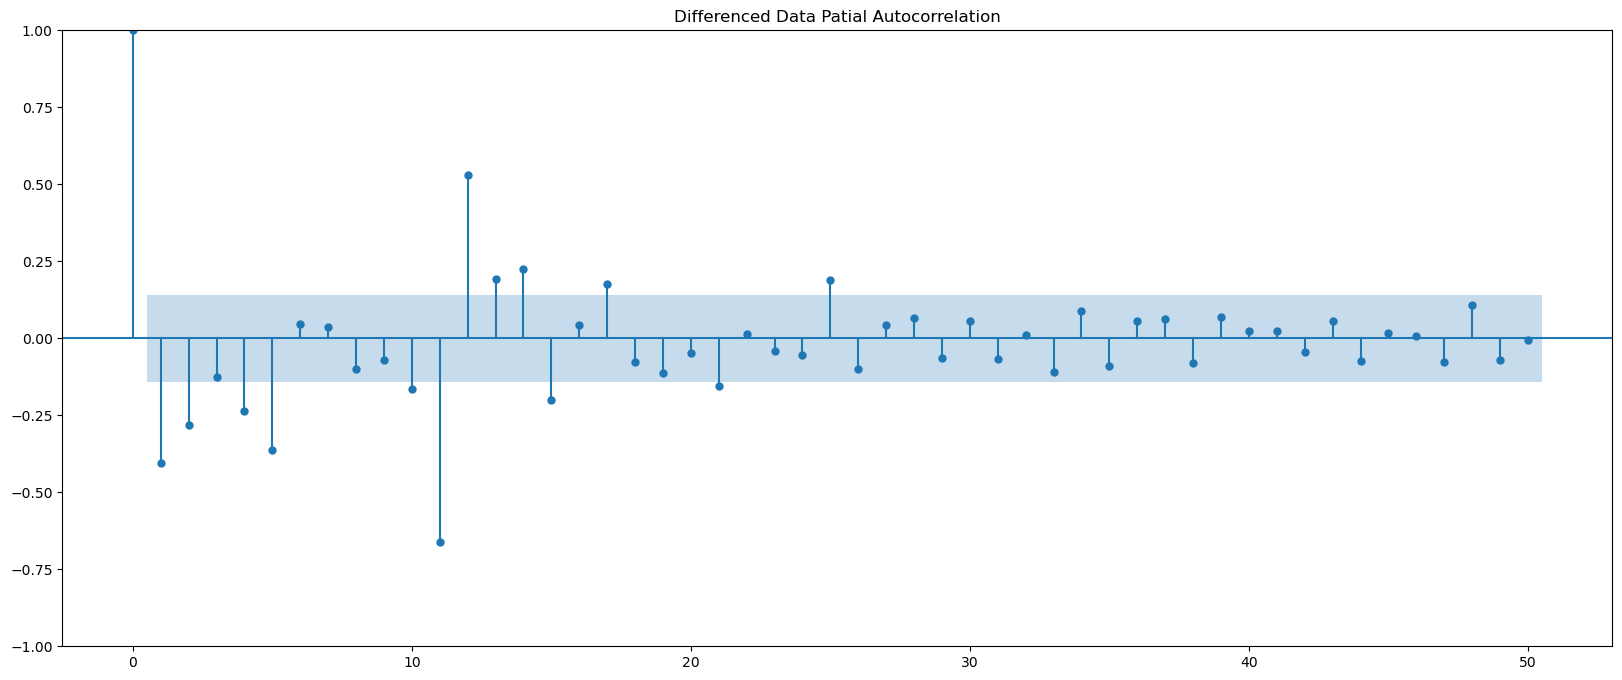

In [329]:
plot_acf(df['RetailSales'].diff().dropna(),lags=50,title='Differenced Data Autocorrelation')
plot_pacf(df['RetailSales'].diff().dropna(),lags=50,title='Differenced Data Patial Autocorrelation')
plt.show()

We see that our ACF plot at the seasonal interval (12) does not taper off. So, we go ahead and take a seasonal differencing of the original series. Before that let us look at the original series.

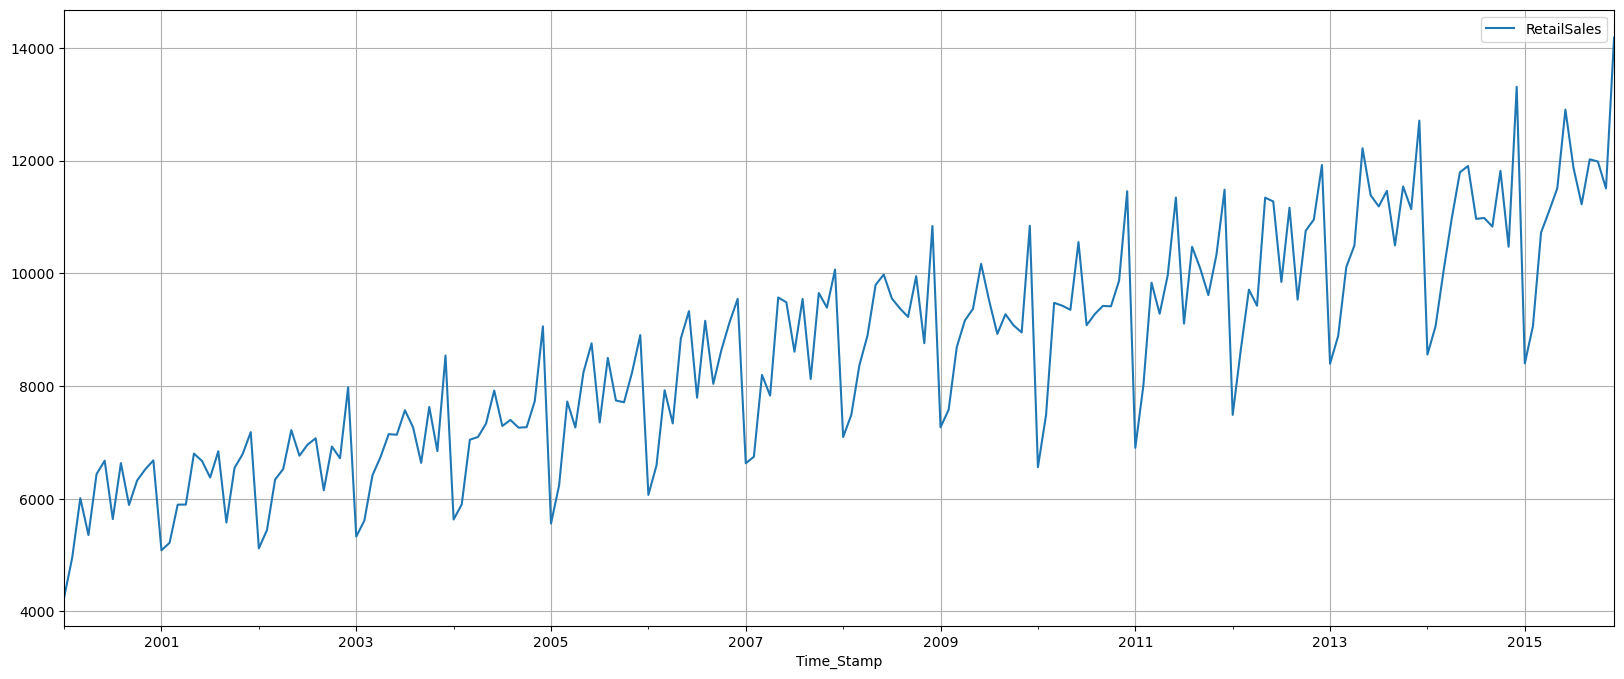

In [332]:
df.plot()
plt.grid();


We see that there is a trend and a seasonality. So, now we take a seasonal differencing and check the series.

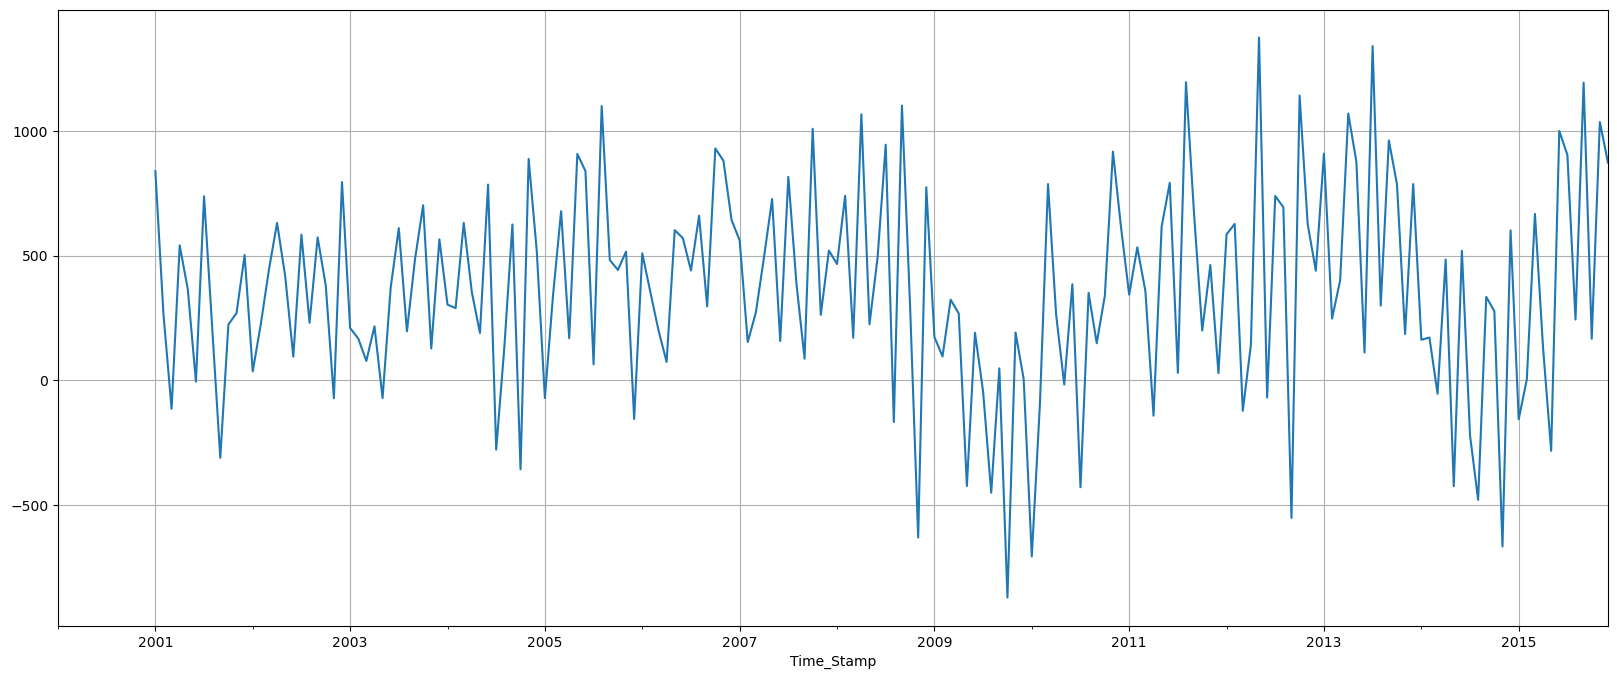

In [335]:
(df['RetailSales'].diff(12)).plot()
plt.grid();

We see that there might be a slight trend which can be noticed in the data. So we take a differencing of first order on the seasonally differenced series.

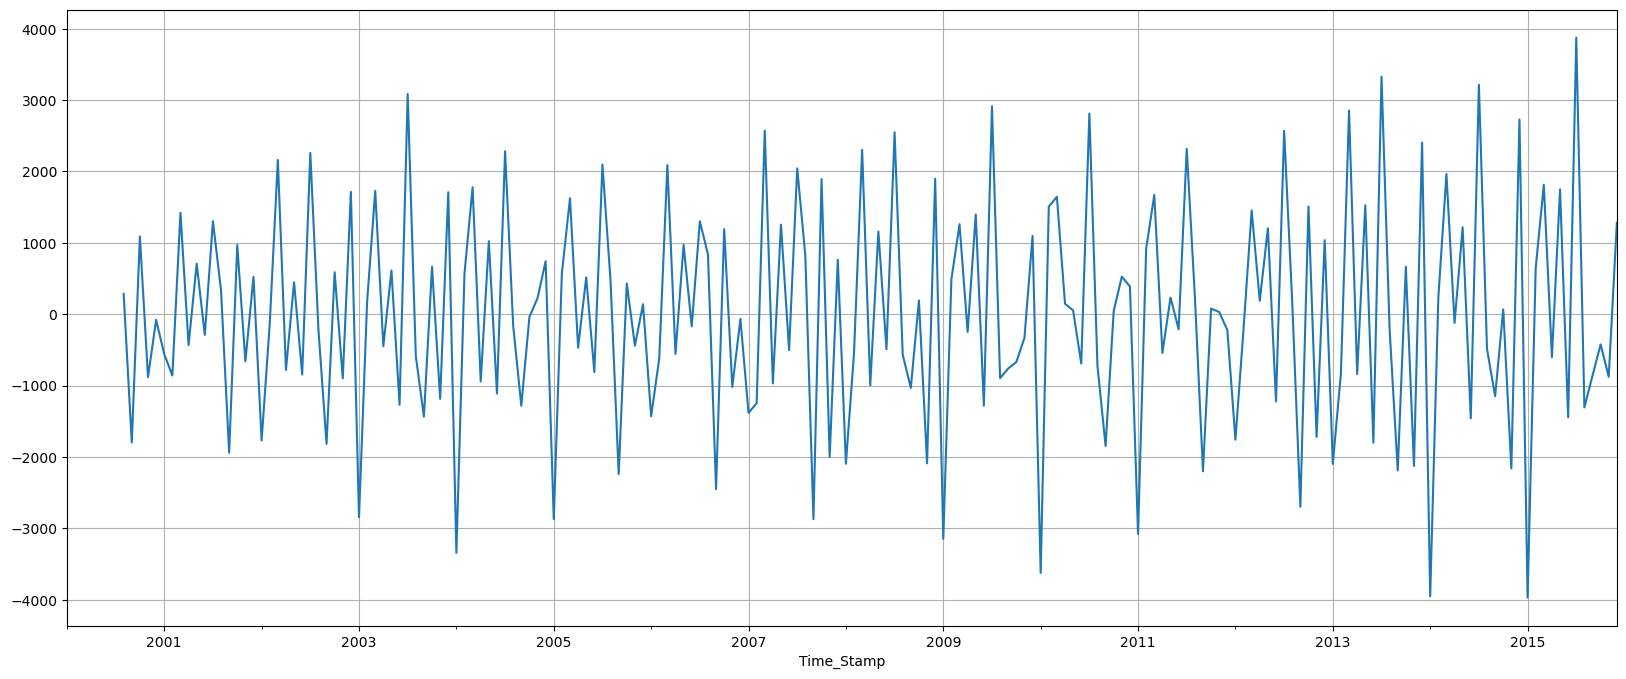

In [338]:
(df['RetailSales'].diff(6)).diff().plot()
plt.grid();

Now we see that there is almost no trend present in the data. Seasonality is only present in the data.

Let us go ahead and check the stationarity of the above series before fitting the SARIMA model.

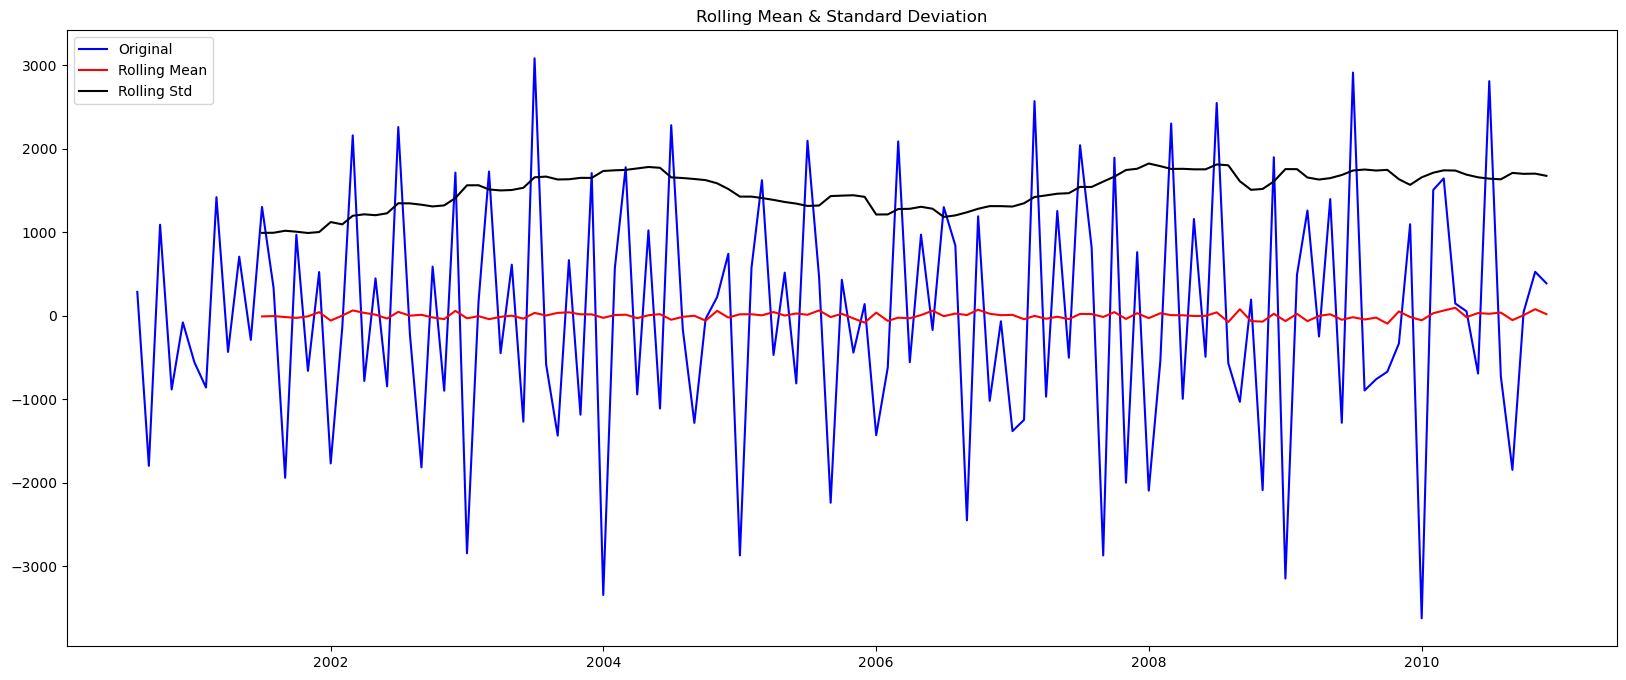

Results of Dickey-Fuller Test:
Test Statistic                  -4.892043
p-value                          0.000036
#Lags Used                      13.000000
Number of Observations Used    111.000000
Critical Value (1%)             -3.490683
Critical Value (5%)             -2.887952
Critical Value (10%)            -2.580857
dtype: float64 



In [342]:
test_stationarity((train['RetailSales'].diff(6).dropna()).diff(1).dropna())

Checking the ACF and the PACF plots for the new modified Time Series.

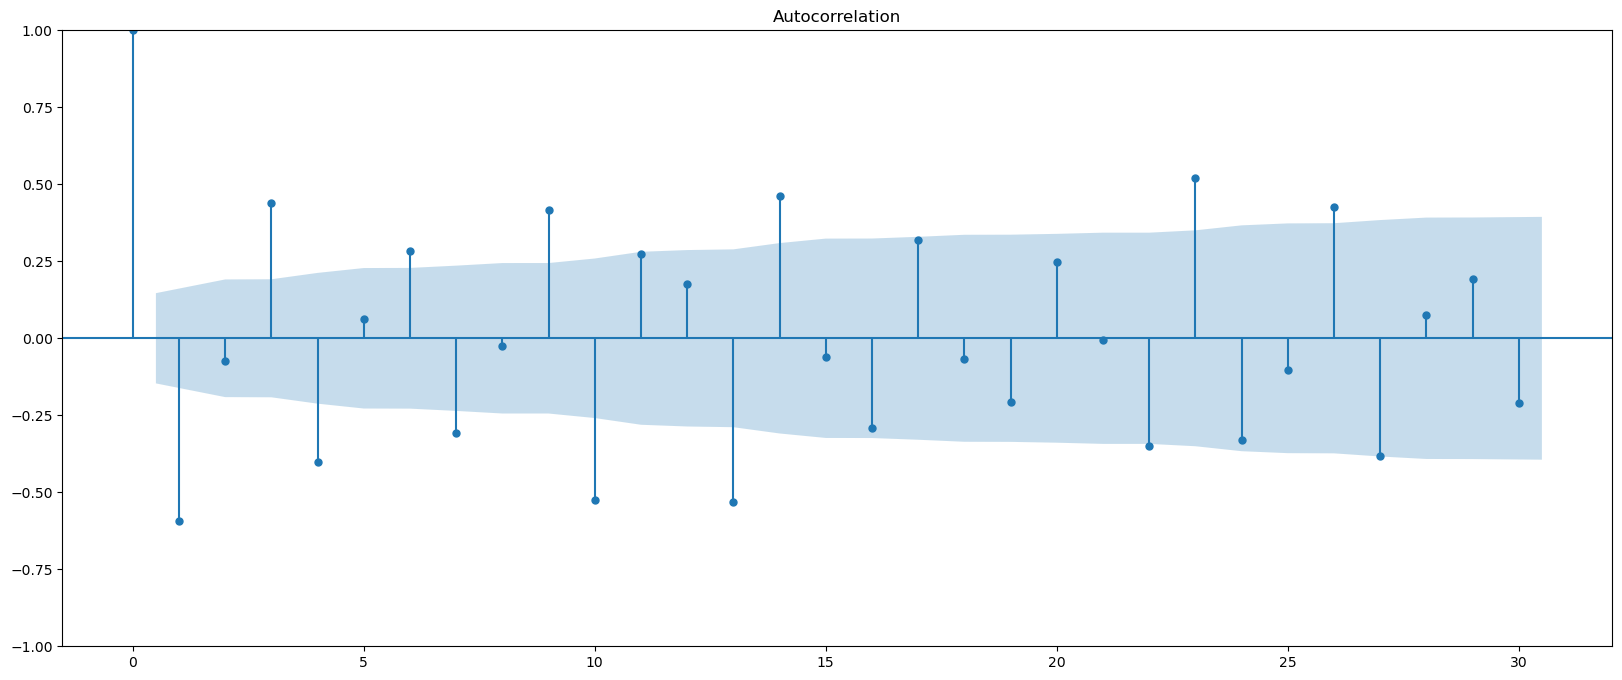

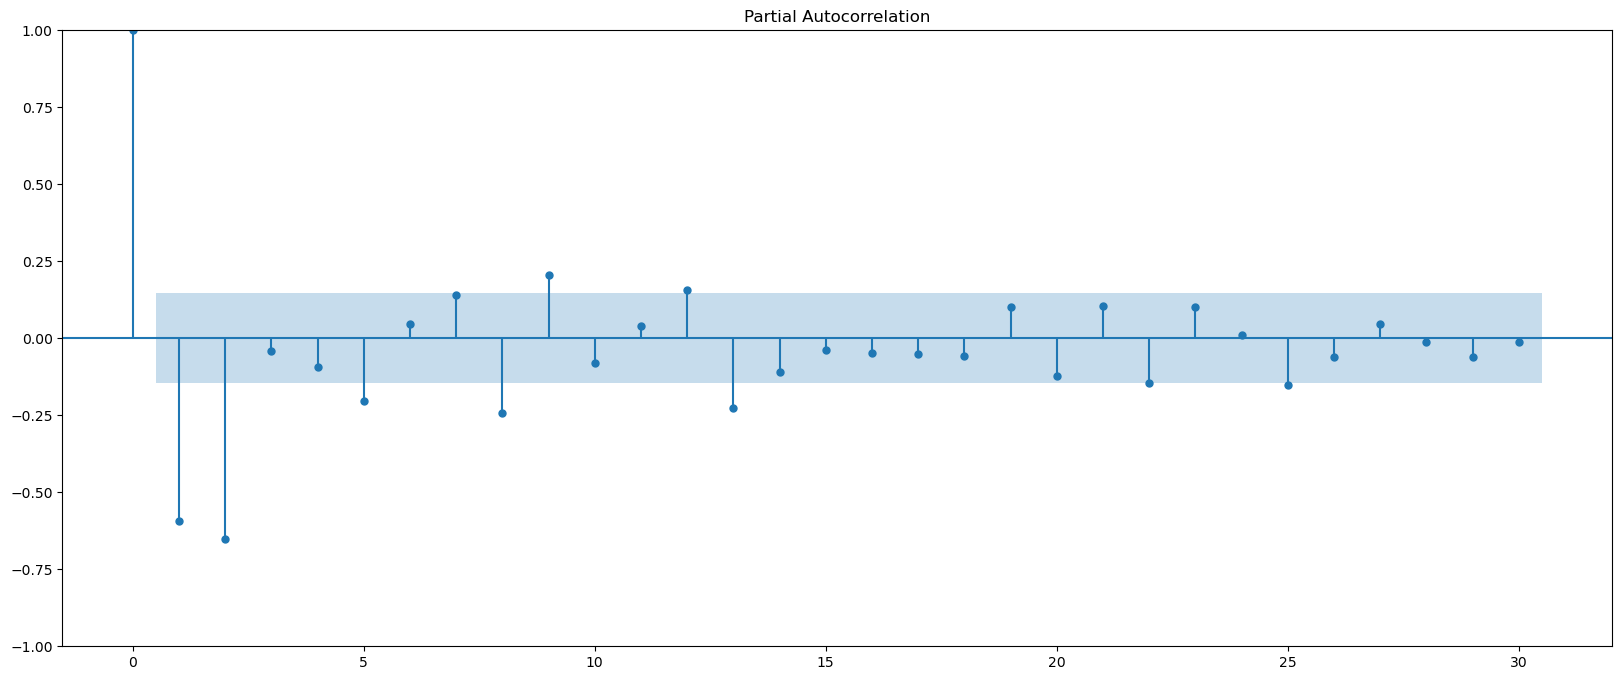

In [345]:
plot_acf((df['RetailSales'].diff(12).dropna()).diff(1).dropna(),lags=30)
plot_pacf((df['RetailSales'].diff(12).dropna()).diff(1).dropna(),lags=30);

Here, we have taken alpha=0.05.

We are going to take the seasonal period as 6. We will keep the p(1) and q(1) parameters same as the ARIMA model.

   -> The Auto-Regressive parameter in an SARIMA model is 'P' which comes from the significant lag after which the PACF plot cuts-off to 0.
   
   -> The Moving-Average parameter in an SARIMA model is 'q' which comes from the significant lag after which the ACF plot cuts-off to 0. Remember to         check the ACF and the PACF plots only at multiples of 12 (since 12 is the seasonal period).
   
By looking at the plots we see that the ACF and the PACF do not directly cut-off to 0.

This is a common problem while building models by looking at the ACF and the PACF plots. But we are able to explain the model.

Please do play around with the data and try out different kinds of transformations and different levels of differencing on this data. We have not taken the logarithm of the series and then trying it out.

In [349]:
import statsmodels.api as sm

manual_SARIMA_12 = sm.tsa.statespace.SARIMAX(train['RetailSales'].values,
                                order=(0, 1, 0),
                                seasonal_order=(1, 1, 3, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
results_manual_SARIMA_12 = manual_SARIMA_12.fit(maxiter=1000)
print(results_manual_SARIMA_12.summary())

                                         SARIMAX Results                                          
Dep. Variable:                                          y   No. Observations:                  132
Model:             SARIMAX(0, 1, 0)x(1, 1, [1, 2, 3], 12)   Log Likelihood               -2010.997
Date:                                    Fri, 30 May 2025   AIC                           4031.995
Time:                                            19:22:49   BIC                           4044.028
Sample:                                                 0   HQIC                          4036.826
                                                    - 132                                         
Covariance Type:                                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12       0.2640         -0       -inf      0

C:\Users\Dell\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Dell\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3014: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


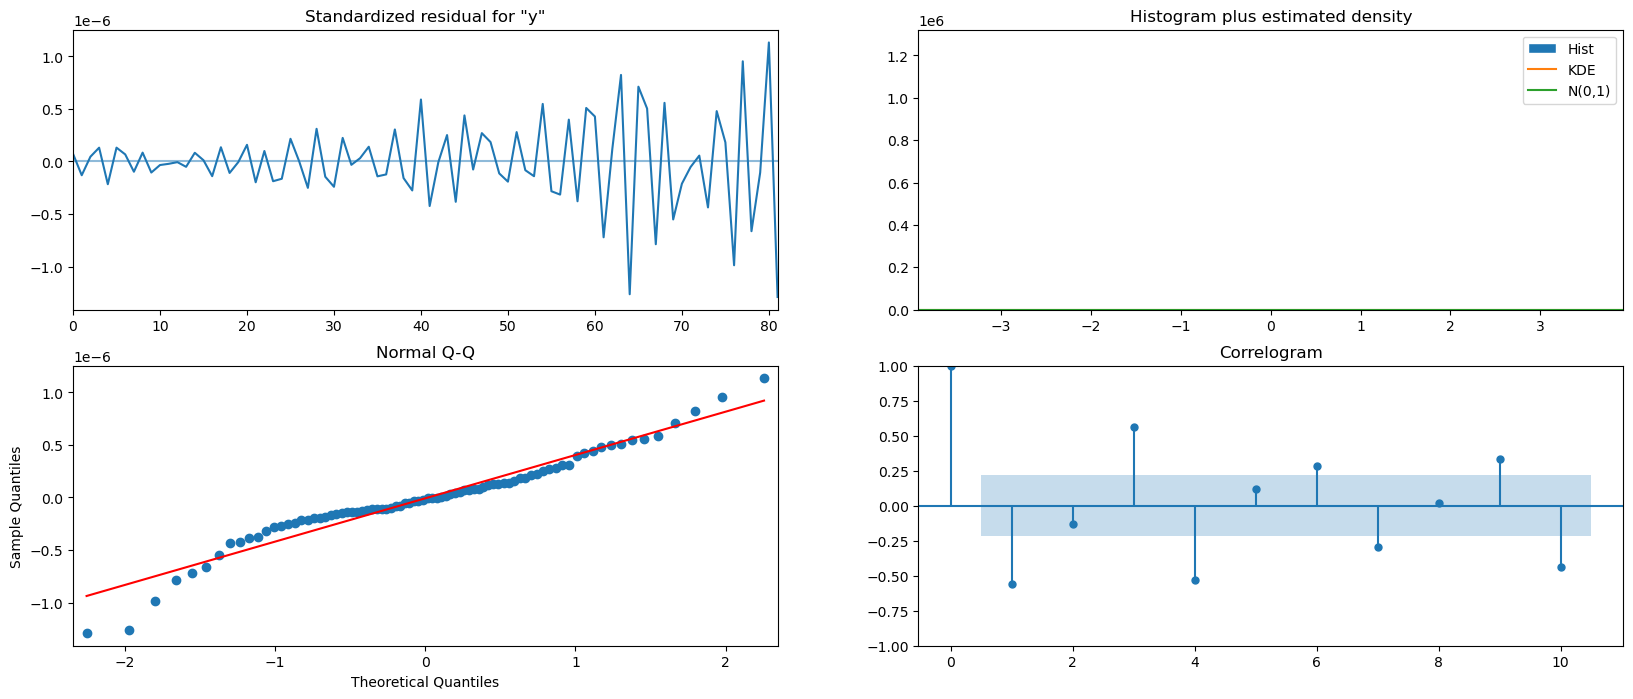

In [351]:
results_manual_SARIMA_12.plot_diagnostics()
plt.show()

The model diagnostics plot looks okay.

# Predict on the Test Set using this model and evaluate the model.

In [357]:
predicted_manual_SARIMA_12 = results_manual_SARIMA_12.get_forecast(steps=len(test))

In [359]:
predicted_manual_SARIMA_12.summary_frame(alpha=0.05).head()

y,mean,mean_se,mean_ci_lower,mean_ci_upper
0,-3114.432522,1.785270e+10,-3.499065e+10,3.499064e+10
1,16845.358623,2.524753e+10,-4.948423e+10,4.948426e+10
2,33361.619545,3.092178e+10,-6.060554e+10,6.060561e+10
3,14462.194894,3.570540e+10,-6.998128e+10,6.998130e+10
4,10982.486475,3.991985e+10,-7.824145e+10,7.824147e+10


In [361]:
rmse = mean_squared_error(test['RetailSales'],predicted_manual_SARIMA_12.predicted_mean,squared=False)
print(rmse)

38008.73767401388


C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [363]:
temp_resultsDf = pd.DataFrame({'RMSE': [rmse]}
                           ,index=['SARIMA(0,1,0)(1,1,3,12)'])


resultsDf = pd.concat([resultsDf,temp_resultsDf])

resultsDf

,RMSE
"ARIMA(2,1,1)",1674.706941
"ARIMA(0,1,2)",1673.985991
"SARIMA(1,1,2)(2,0,2,12)",576.186863
"SARIMA(0,1,0)(1,1,3,12)",38008.737674


# Building the most optimum model on the Full Data.

In [366]:
full_data_model = sm.tsa.statespace.SARIMAX(df['RetailSales'],
                                order=(1,1,2),
                                seasonal_order=(2, 0, 2, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
results_full_data_model = full_data_model.fit(maxiter=1000)
print(results_full_data_model.summary())

C:\Users\Dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                        RetailSales   No. Observations:                  192
Model:             SARIMAX(1, 1, 2)x(2, 0, 2, 12)   Log Likelihood               -1201.357
Date:                            Fri, 30 May 2025   AIC                           2418.714
Time:                                    19:30:20   BIC                           2443.513
Sample:                                01-01-2000   HQIC                          2428.782
                                     - 12-01-2015                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8415      0.047    -18.068      0.000      -0.933      -0.750
ma.L1          0.1332      5.909   

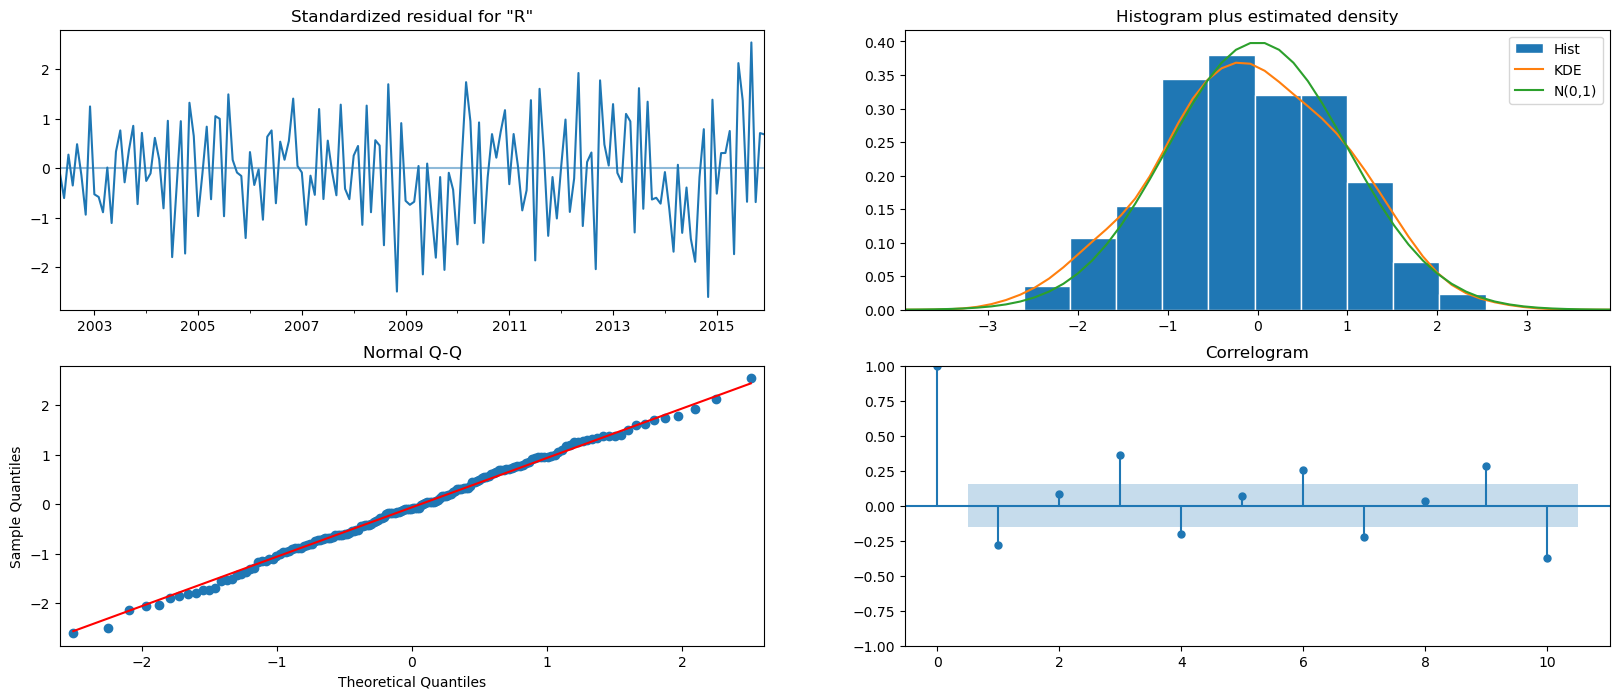

In [368]:
results_full_data_model.plot_diagnostics();

# Evaluate the model on the whole and predict 17 months into the future (till the end of next year).

In [371]:
predicted_manual_SARIMA_12_full_data = results_full_data_model.get_forecast(steps=17)

In [373]:
predicted_manual_SARIMA_12_full_data.summary_frame(alpha=0.05).head()

RetailSales,mean,mean_se,mean_ci_lower,mean_ci_upper
2016-01-01,8805.186813,347.303350,8124.484756,9485.888871
2016-02-01,9631.988032,360.126145,8926.153759,10337.822305
2016-03-01,11490.271709,360.300780,10784.095158,12196.448261
2016-04-01,11620.764747,369.422043,10896.710847,12344.818647
2016-05-01,12458.457414,370.119553,11733.036420,13183.878409


In [375]:
rmse = mean_squared_error(df['RetailSales'],results_full_data_model.fittedvalues,squared=False)
print('RMSE of the Full Model',rmse)

RMSE of the Full Model 604.531555842437


C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [377]:
pred_full_manual_SARIMA_date = predicted_manual_SARIMA_12_full_data.summary_frame(alpha=0.05).set_index(pd.date_range(start='2015-08-01',end='2016-12-01', freq='MS'))

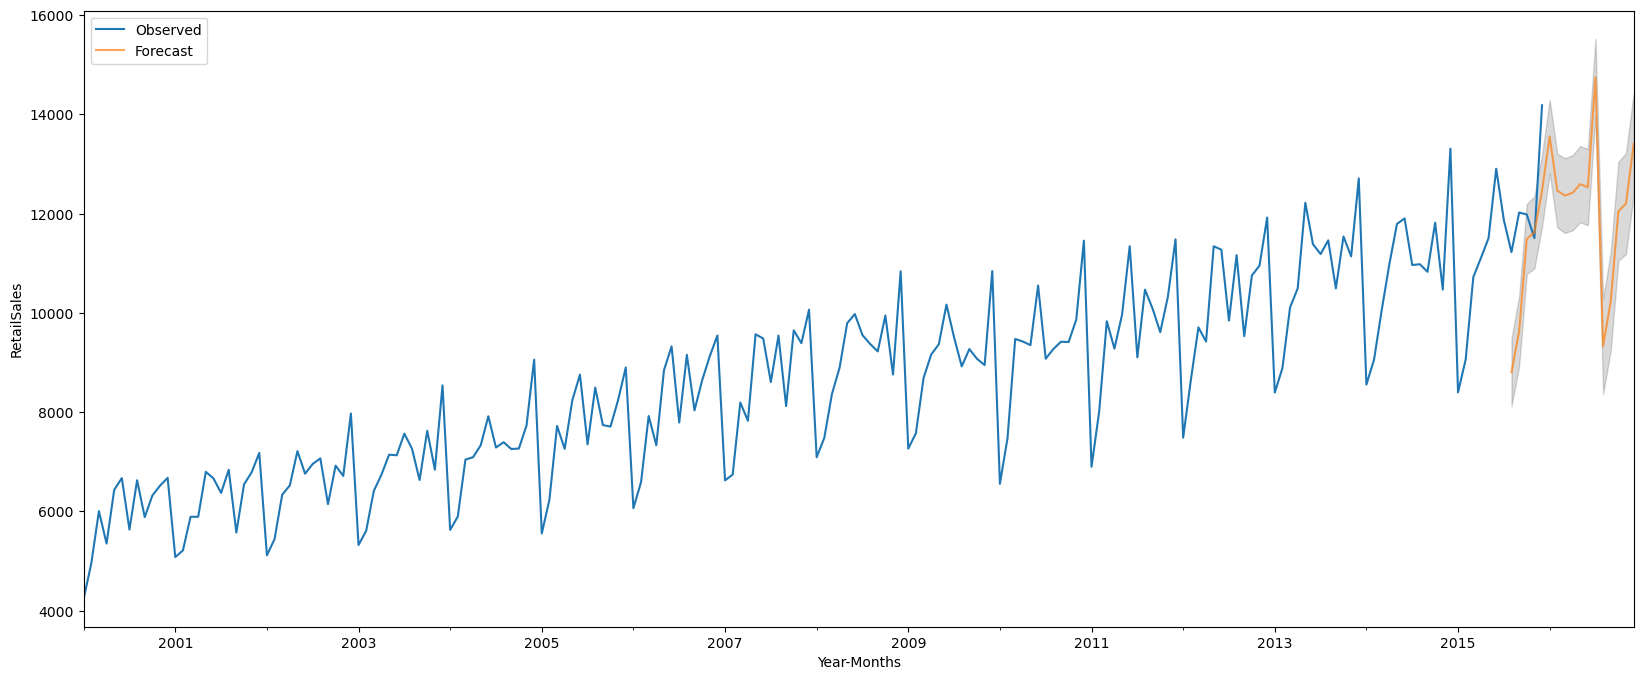

In [379]:
# plot the forecast along with the confidence band

axis = df['RetailSales'].plot(label='Observed')
pred_full_manual_SARIMA_date['mean'].plot(ax=axis, label='Forecast', alpha=0.7)
axis.fill_between(pred_full_manual_SARIMA_date.index, pred_full_manual_SARIMA_date['mean_ci_lower'], 
                  pred_full_manual_SARIMA_date['mean_ci_upper'], color='k', alpha=.15)
axis.set_xlabel('Year-Months')
axis.set_ylabel('RetailSales')
plt.legend(loc='best')
plt.show()

In [381]:
resultsDf

,RMSE
"ARIMA(2,1,1)",1674.706941
"ARIMA(0,1,2)",1673.985991
"SARIMA(1,1,2)(2,0,2,12)",576.186863
"SARIMA(0,1,0)(1,1,3,12)",38008.737674


# END